In [1]:
# فرا خوانی پکیج های مورد نیاز
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
import warnings

In [2]:
# بارگزاری دیتاست از فایل CSV
df_customers = pd.read_csv("Telco-Customer-Churn.csv")

In [3]:
# آنالیز اولیه ویژگی ها با استفاده از sweetviz
report = sv.analyze(df_customers)

                                             |          | [  0%]   00:00 -> (? left)


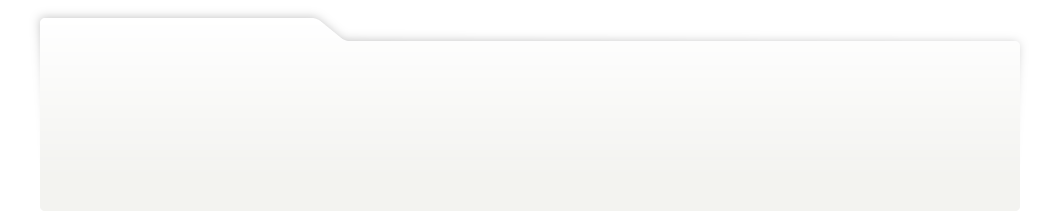
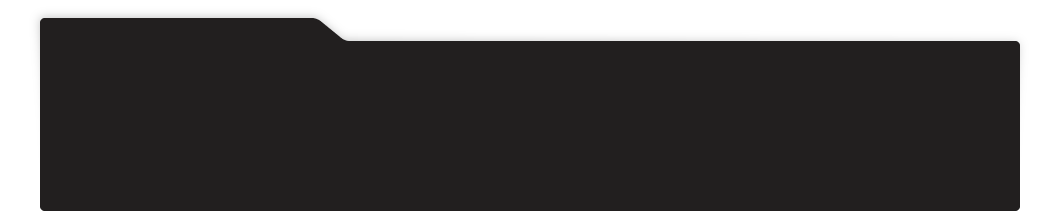
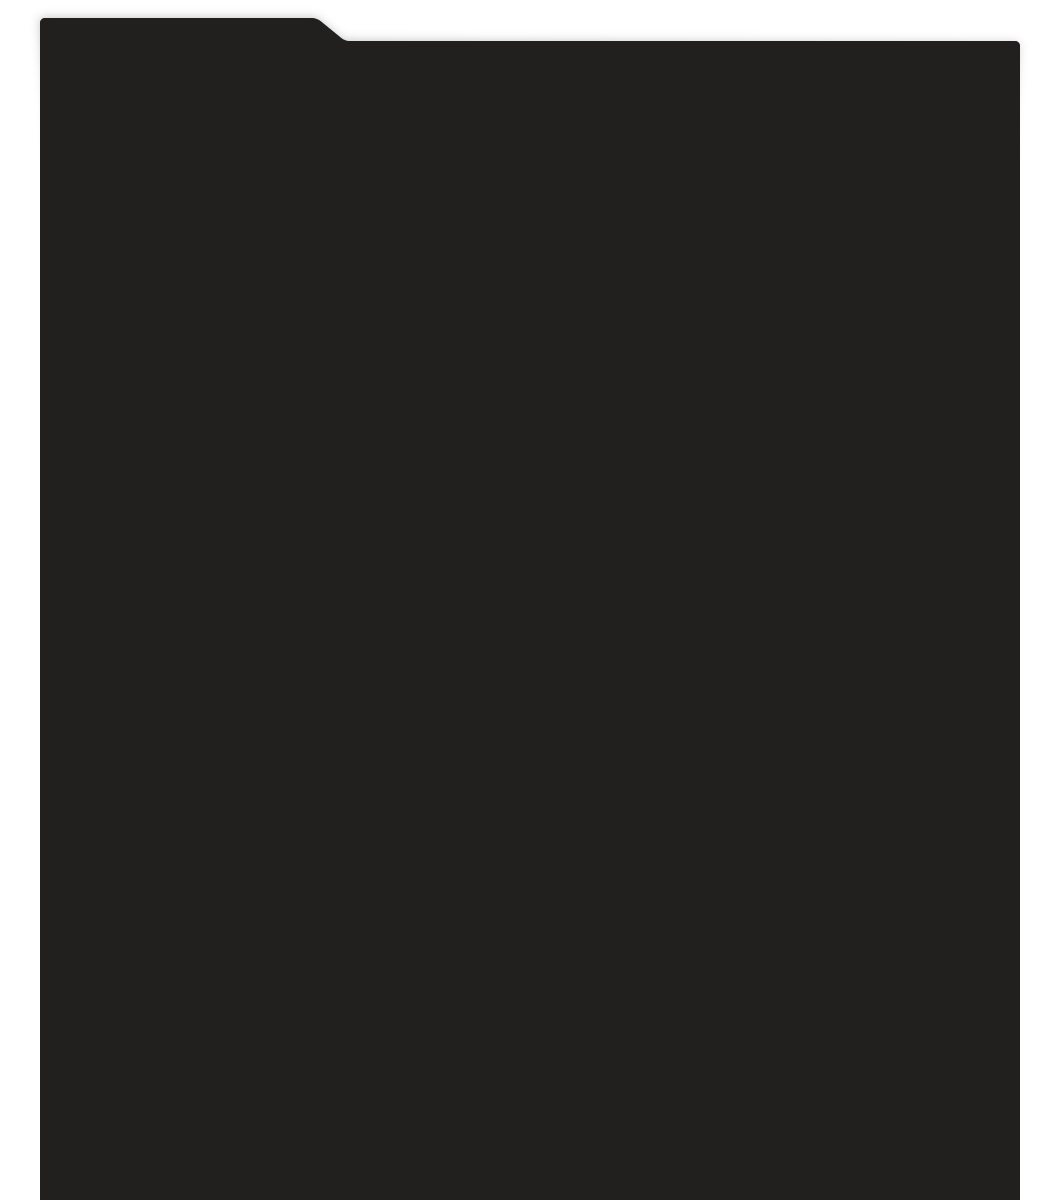
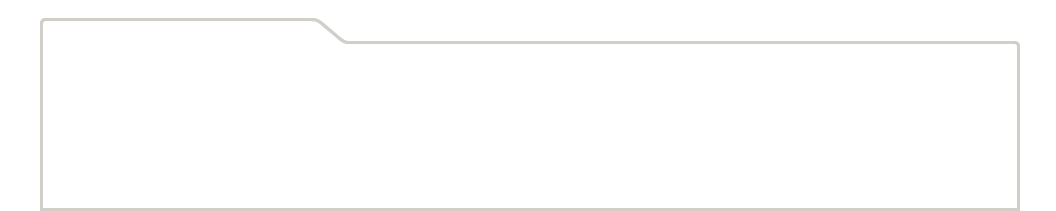
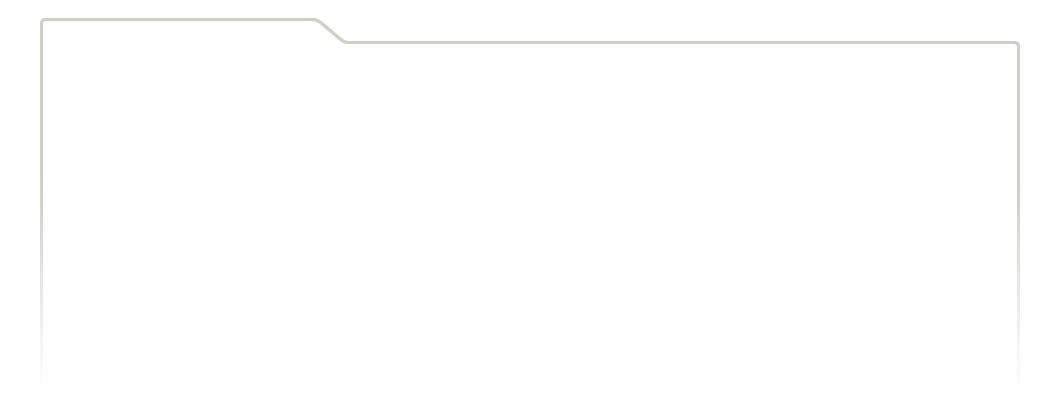
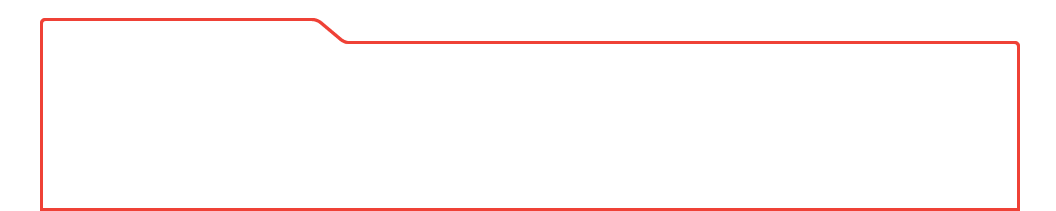
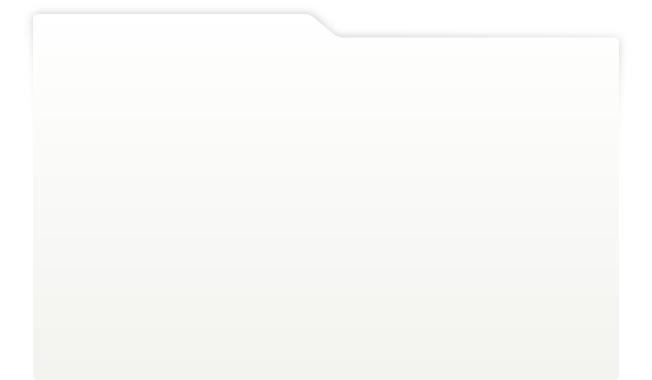
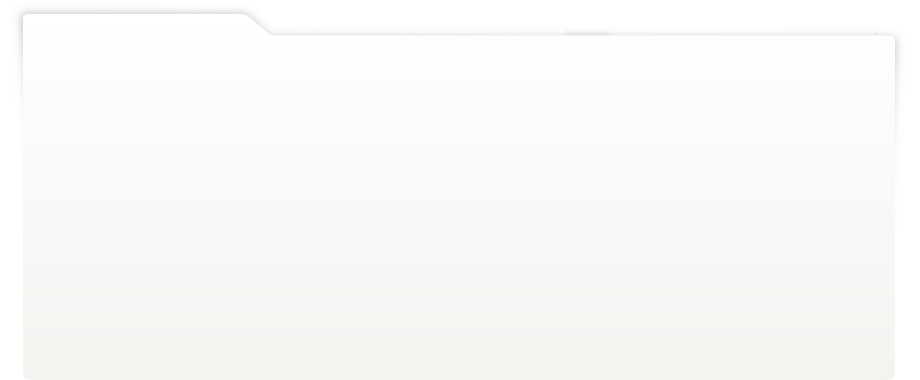
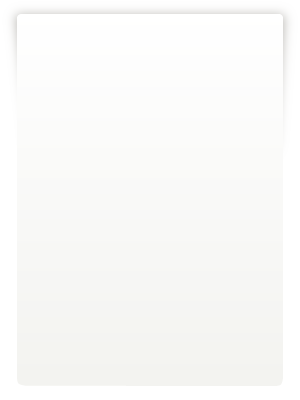
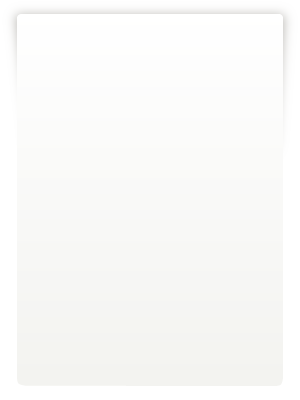
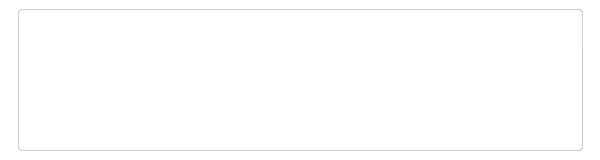
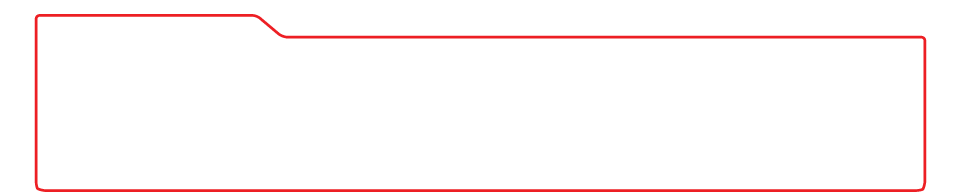
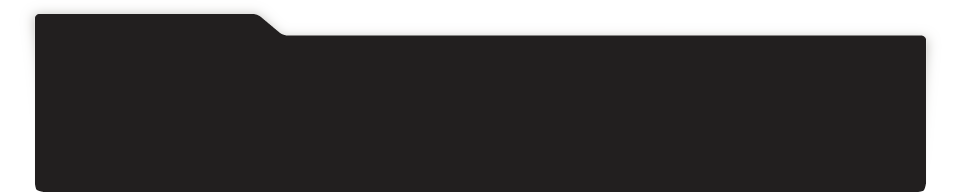
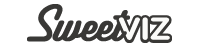
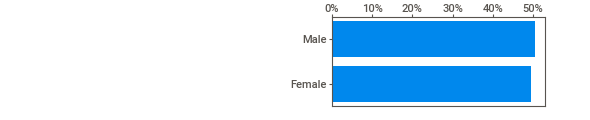
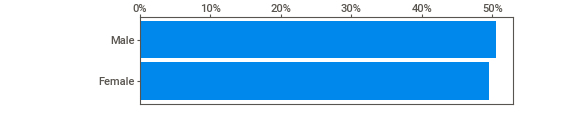
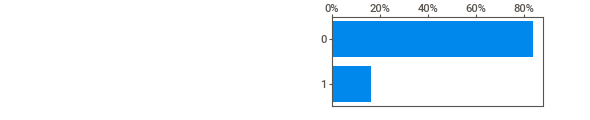
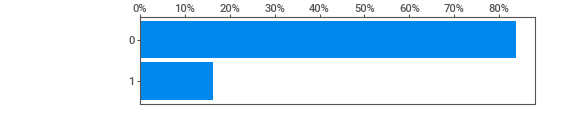
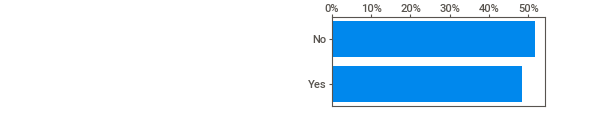
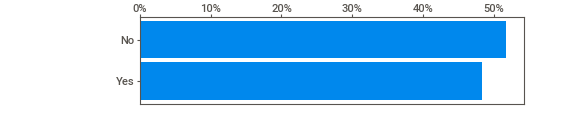
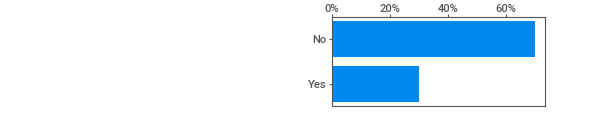
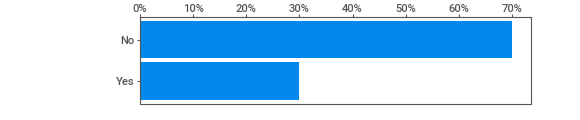
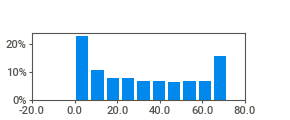
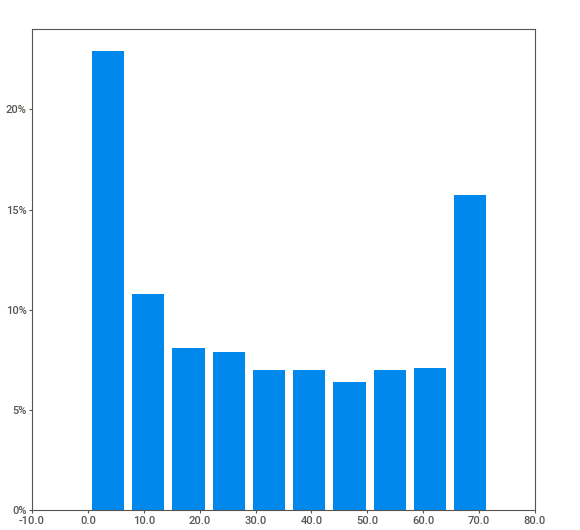
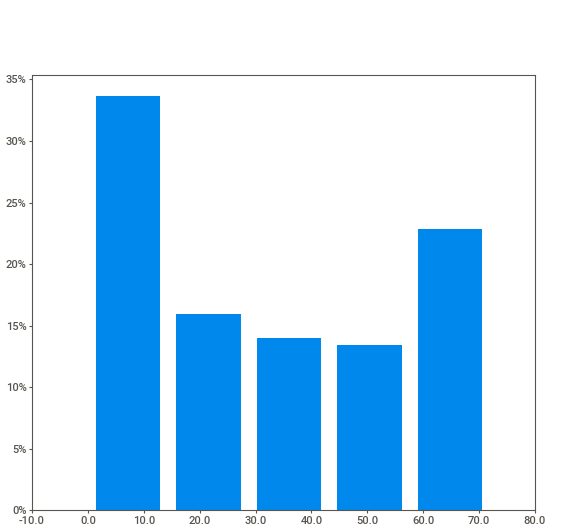
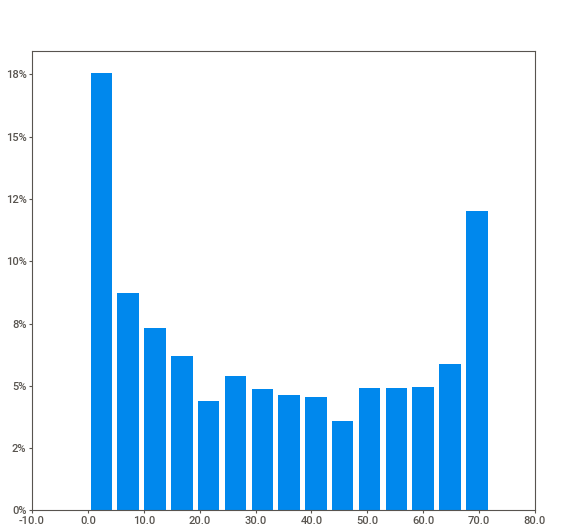
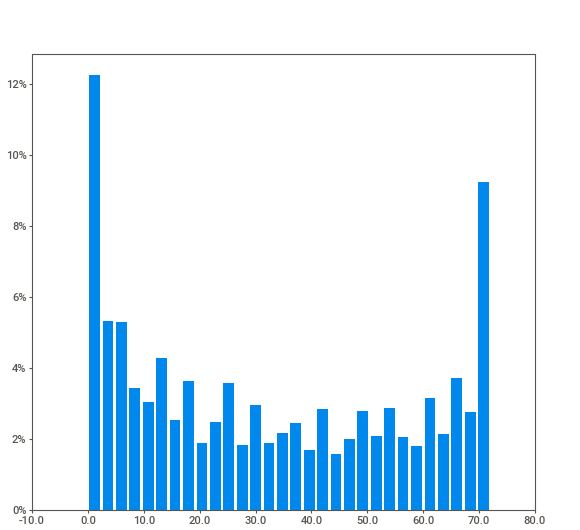
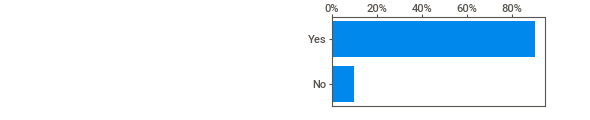
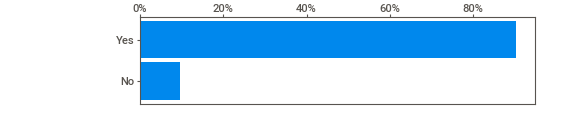
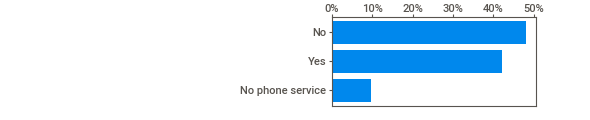
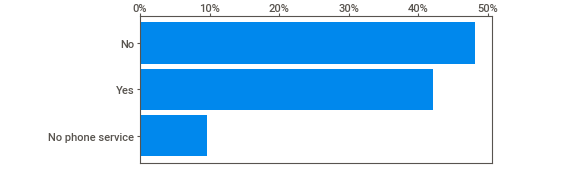
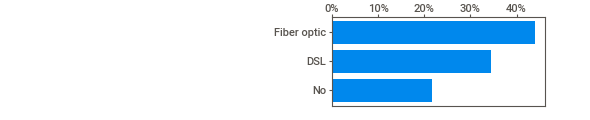
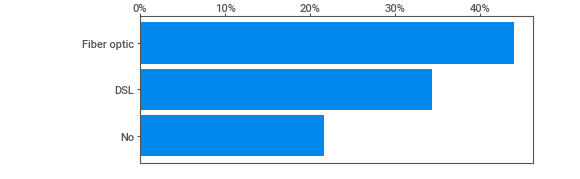
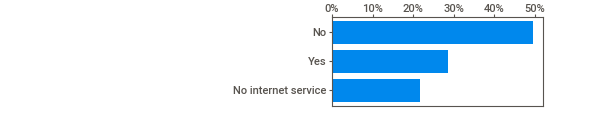
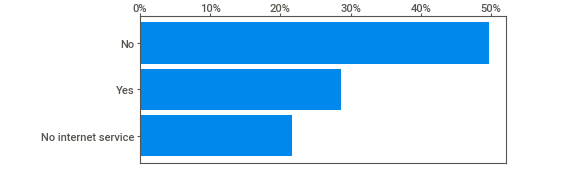
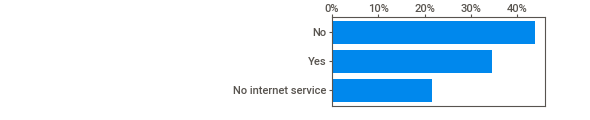
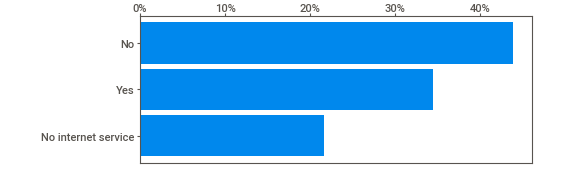
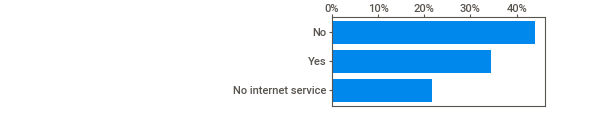
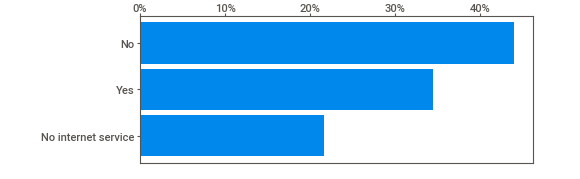
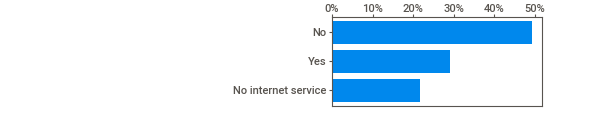
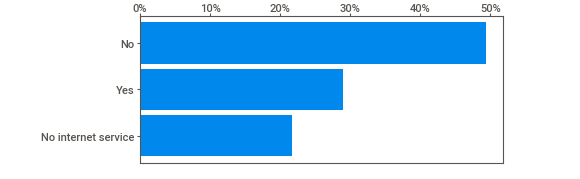
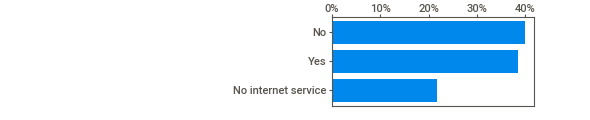
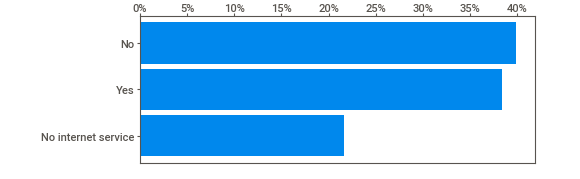
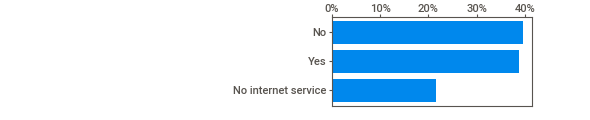
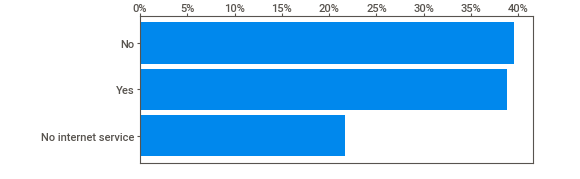
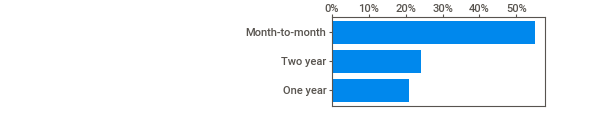
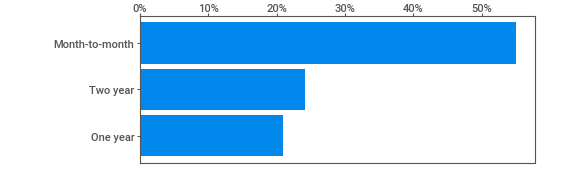
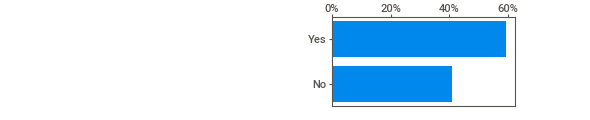
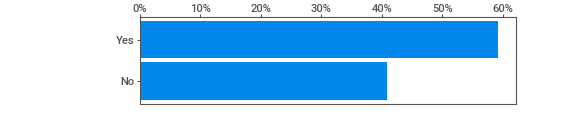
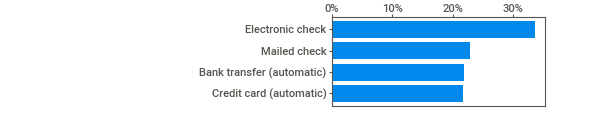
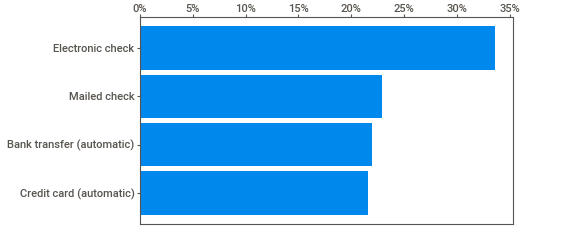
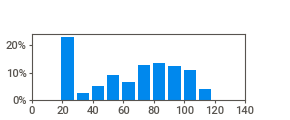
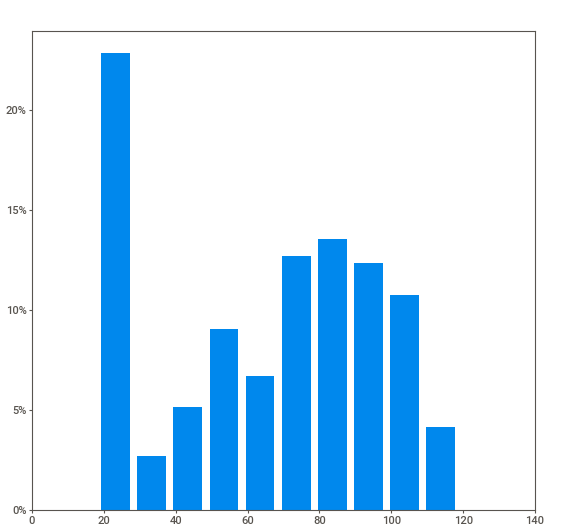
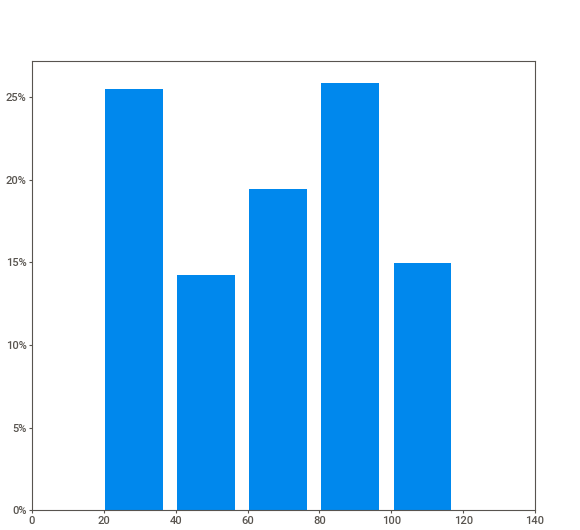
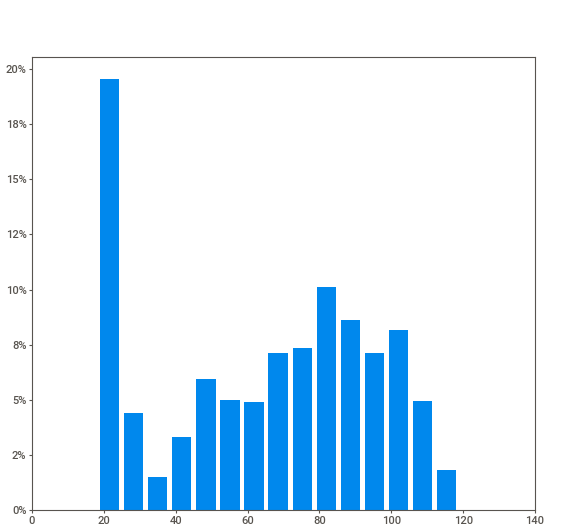
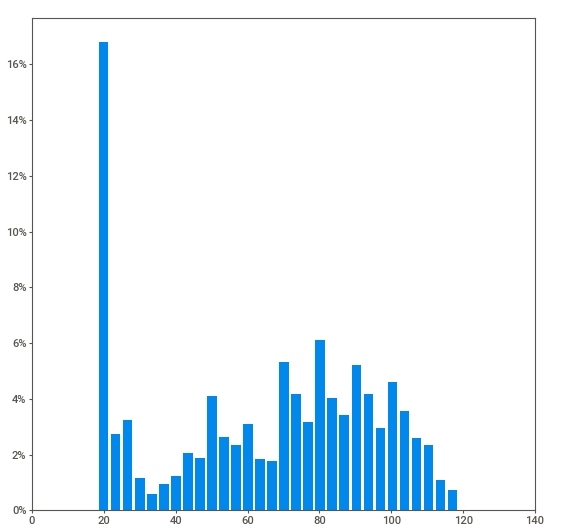
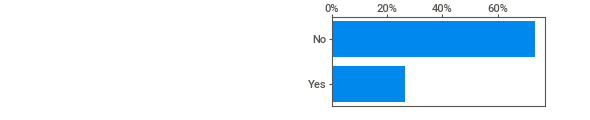
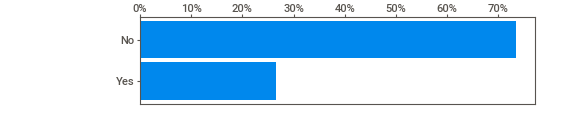
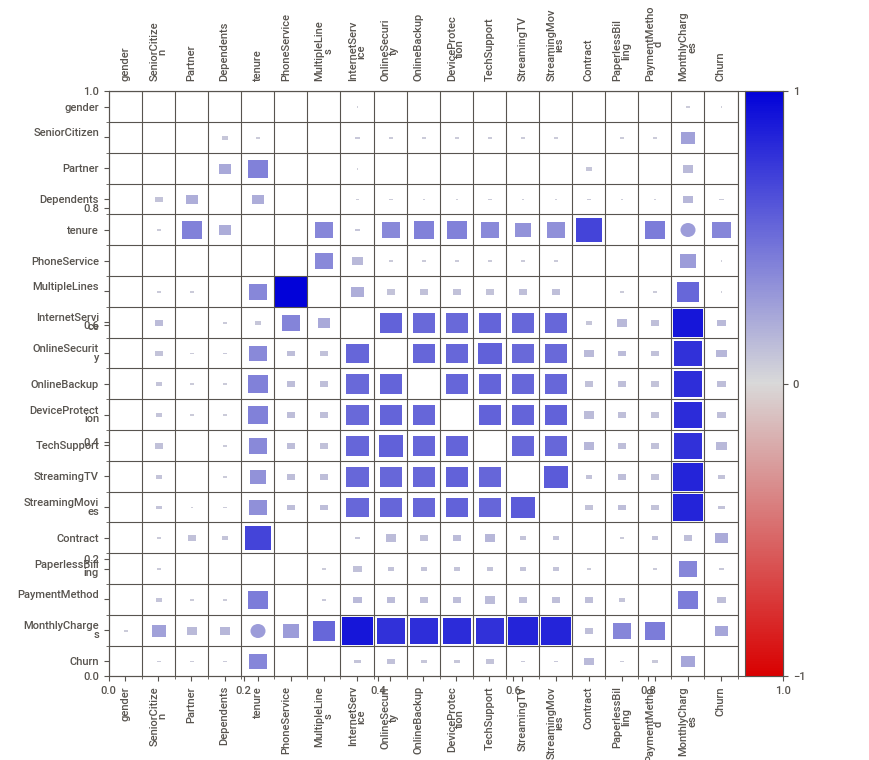
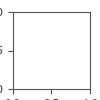

In [4]:
# نمایش نتایج
report.show_notebook()

## Initial Data Review

In [5]:
# نمایش پنج سطر اول دیتاست جهت آشنایی اولیه
df_customers.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# بررسی ابعاد داده
df_customers.shape

(7043, 21)

In [7]:
# نمایش نام ستون ها
df_customers.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
# نمایش نوع داده ستون ها
df_customers.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
# نمایش مقادیر یکتا ستون ها
df_customers.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [10]:
# نمایش نوع داده ستون ها و تعداد مقادیر غیر خالی
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Data Cleanup

In [11]:
# جایگزاری فضا های خالی با مقدار nan با هدف مدیریت بهتر missing vlues
df_customers = df_customers.replace(" ", np.nan)

In [12]:
# تبدیل نوع داده ستون TotalCharges به مقادیر float
df_customers["TotalCharges"] = df_customers["TotalCharges"].astype("float")
# تبدیل نوع داده ستون SeniorCitizen به مقادیر str
df_customers["SeniorCitizen"] = df_customers["SeniorCitizen"].astype("str")

In [13]:
# حذف ستون customerID چونکه برای آموزش مدل کاربردی ندارد
df_customers.drop(columns="customerID", inplace=True)

In [14]:
# بررسی تعداد سطر های تکراری
df_customers.duplicated().sum()

np.int64(22)

In [15]:
# بررسی تعداد ستون های تکراری
duplicated_columns = df_customers.T.duplicated()
df_customers.columns[duplicated_columns]

Index([], dtype='object')

In [16]:
# حذف سطر های تکراری
df_customers.drop_duplicates(inplace=True)

In [17]:
# بررسی تعداد مقادیر گمشده هر ستون
df_customers.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [18]:
# تفکیک ویژگی های عددی
numerical_features = df_customers.select_dtypes(["int64", "float64"])
# تفکیک ویژگی های دسته ای
category_features = df_customers.select_dtypes("object")

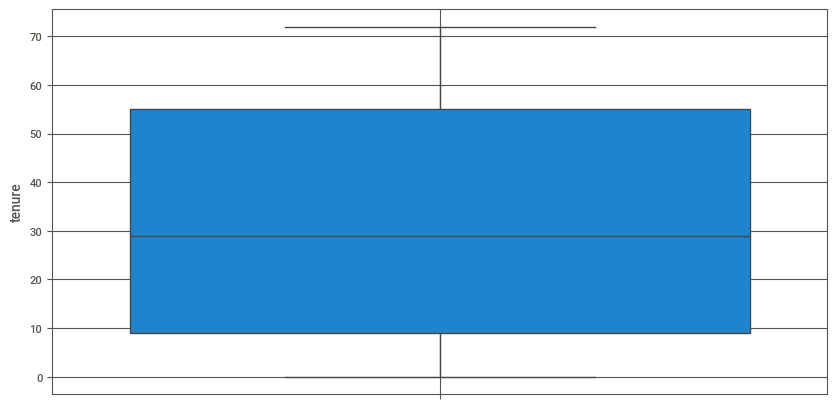

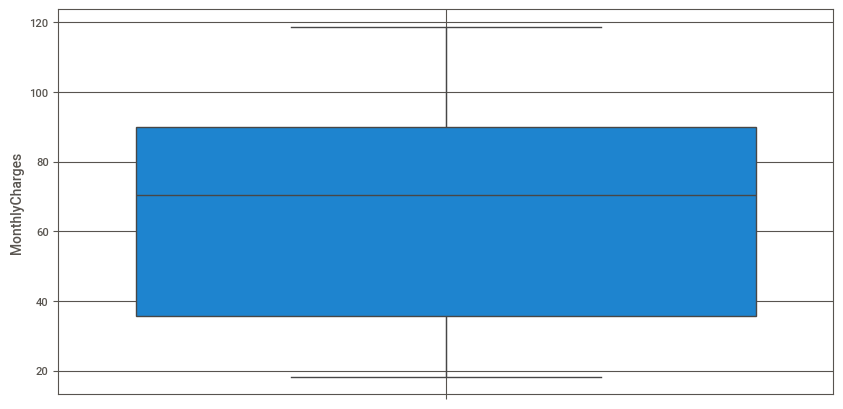

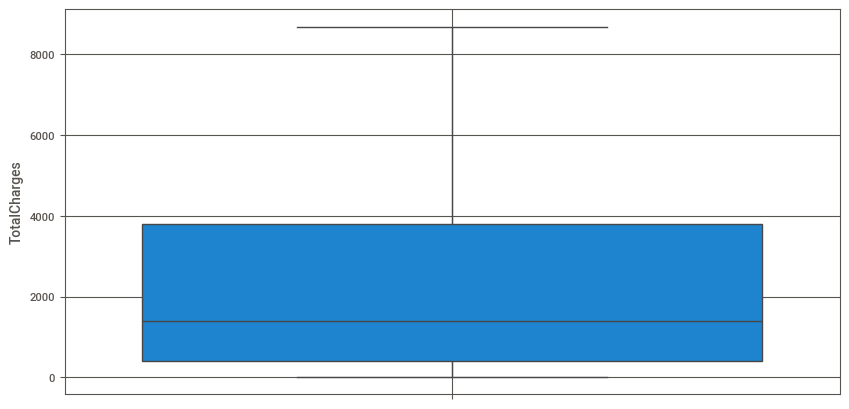

In [19]:
# رسم نمودار Boxplot برای شناسایی مقادیر پرت در ویژگی های عددی
for column in numerical_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=numerical_features, y=column)
    plt.grid()
    plt.show()

In [20]:
# تابع robust z-score برای شناسایی ردیف هایی که دارای مقادیر پرت هستند
def robust_zscore(data=None, columns=None):
    medians = np.median(data[columns], axis=0)
    MAD = np.median(np.abs(data[columns] - medians), axis=0)
    mi = (0.6745 * (data[columns] - medians)) / MAD

    z_threshold = 3

    outlier_detect = np.array(np.abs(mi) > z_threshold)

    outlier_indices = data[columns].index[outlier_detect.any(axis=1)]
    return outlier_indices

In [21]:
robust_zscore(data=df_customers, columns=["tenure", "MonthlyCharges", "TotalCharges"])

Index([], dtype='int64')

## Descriptive Analysis

In [22]:
# نمایش آماری ویژگی های عددی
numerical_features.describe()

,tenure,MonthlyCharges,TotalCharges
count,7021.000000,7021.000000,7010.000000
mean,32.469449,64.851894,2290.353388
std,24.534965,30.069001,2266.820832
min,0.000000,18.250000,18.800000
25%,9.000000,35.750000,408.312500
50%,29.000000,70.400000,1403.875000
75%,55.000000,89.900000,3807.837500
max,72.000000,118.750000,8684.800000


In [23]:
# تحلیل توضیع داده ها با استفاده آمار توصیفی
for column in numerical_features:
    print(column)
    print(f"mean => {numerical_features[column].mean()}, median => {numerical_features[column].median()}")
    print(f"variance => {numerical_features[column].var()}, standard deviation => {numerical_features[column].std()}")
    print(f"skewness => {numerical_features[column].skew()}, kurtosis => {numerical_features[column].kurt()}")
    print("." * 100)

tenure
mean => 32.46944879646774, median => 29.0
variance => 601.9644867189234, standard deviation => 24.53496457545687
skewness => 0.23554168006988707, kurtosis => -1.3880898876980527
....................................................................................................
MonthlyCharges
mean => 64.85189431704886, median => 70.4
variance => 904.1448183483736, standard deviation => 30.069000953612903
skewness => -0.22409728909692606, kurtosis => -1.2539735898470004
....................................................................................................
TotalCharges
mean => 2290.3533880171185, median => 1403.875
variance => 5138476.683244691, standard deviation => 2266.8208317475583
skewness => 0.9583220586626408, kurtosis => -0.23837324985924724
....................................................................................................


In [24]:
numerical_features["Churn"] = df_customers["Churn"].map({"No": 0, "Yes": 1})

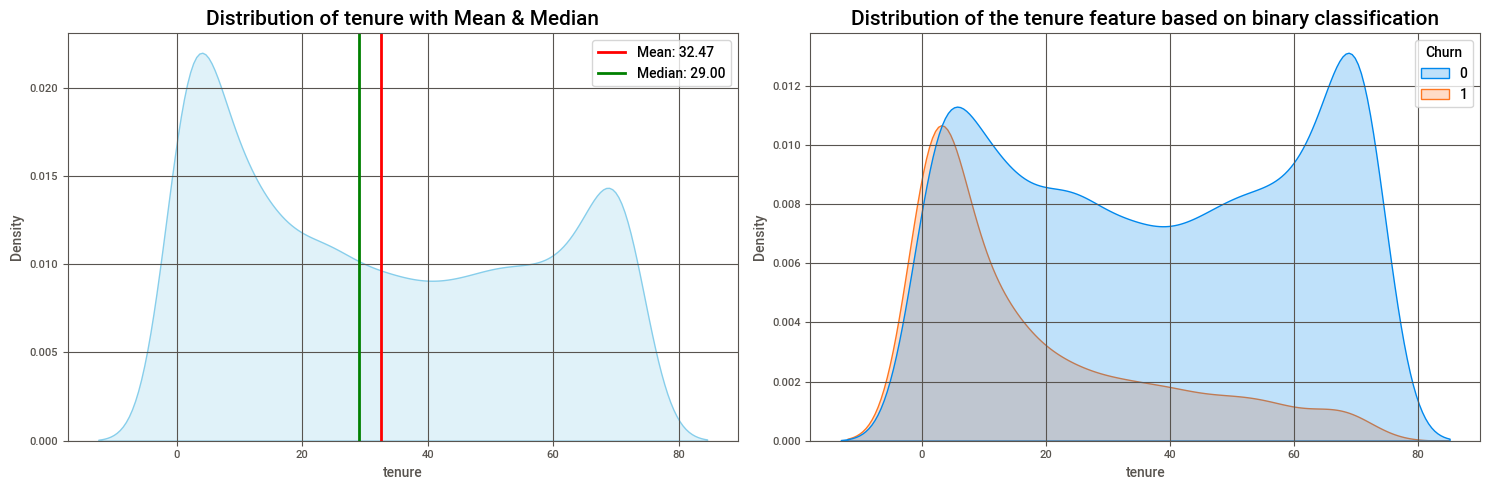

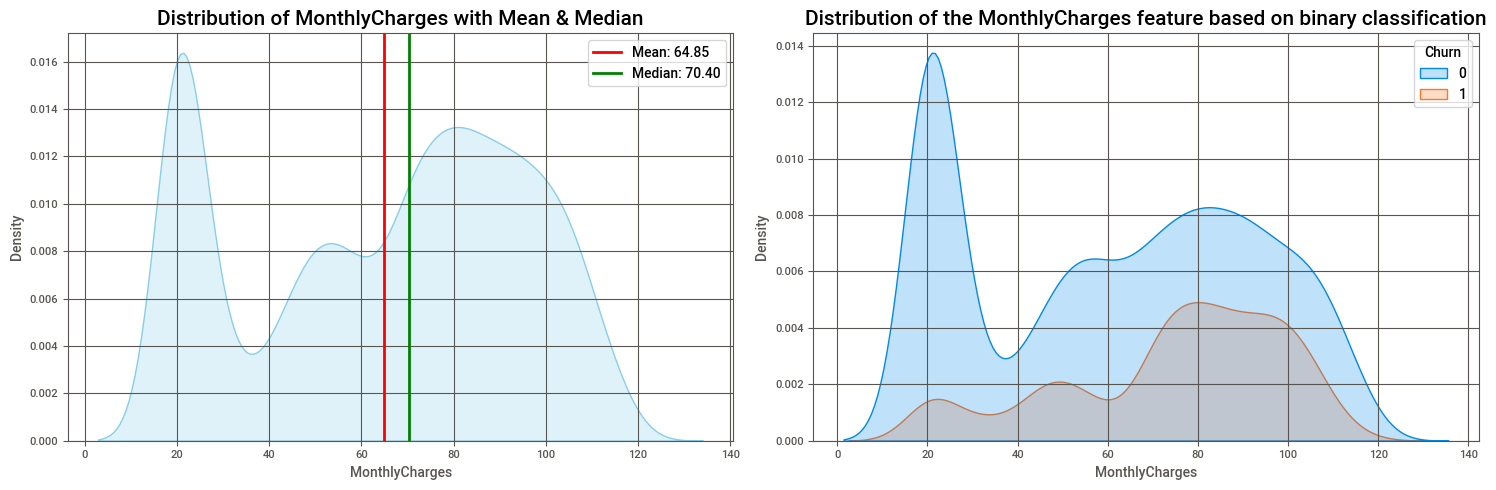

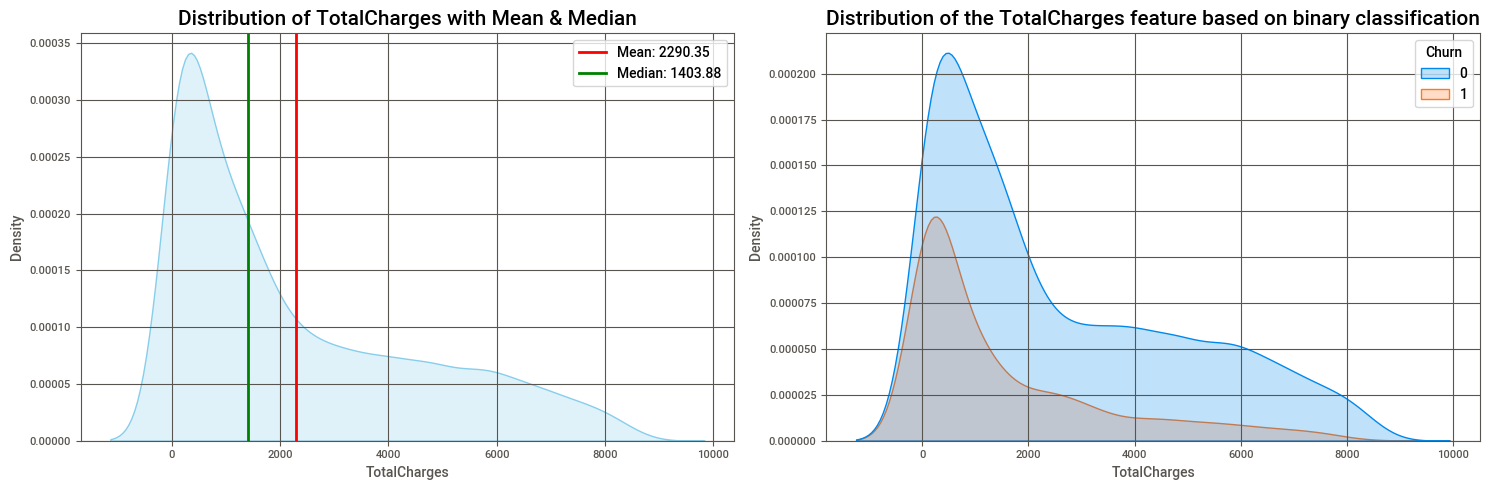

In [57]:
for column in numerical_features:
    if column == "Churn":
        continue

    # ایجاد اشکال
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # نمایش توزیع ویژگی های عددی با استفاده از نمودار KDE
    sns.kdeplot(data=numerical_features, x=column, color='skyblue', fill=True, ax=axes[0])
    
    # ۳. محاسبه میانگین و میانه
    mean_val = numerical_features[column].mean()
    median_val = numerical_features[column].median()

    # ۴. رسم خطوط عمودی برای میانگین و میانه
    axes[0].axvline(mean_val, color='red', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[0].axvline(median_val, color='green', linewidth=2, label=f'Median: {median_val:.2f}')
    
    axes[0].set_title(f'Distribution of {column} with Mean & Median', fontsize=15)
    axes[0].legend()
    axes[0].grid()

    # نمایش توزیع ویژگی های عددی بر اساس طبقه بندی دو کلاسه با استفاده از نمودار KDE
    sns.kdeplot(data=numerical_features, x=column, color='skyblue', fill=True, hue="Churn", ax=axes[1])
    axes[1].set_title(f'Distribution of the {column} feature based on binary classification', fontsize=15)
    axes[1].grid()
    
    plt.tight_layout()
    plt.show()

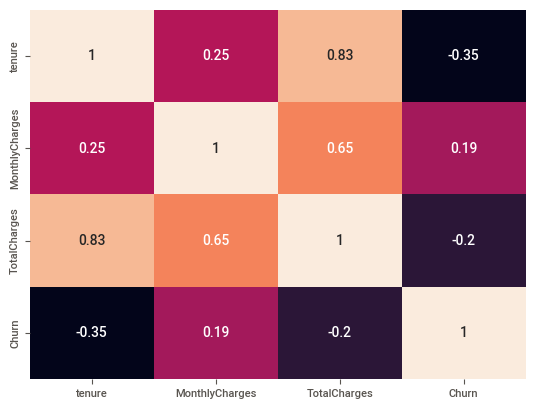

In [26]:
# تحلیل همبستگی ویژگی های عددی با استفاده از نمودار heatmap
sns.heatmap(data=numerical_features.corr(method="pearson"), annot=True, cbar=False)
plt.show()

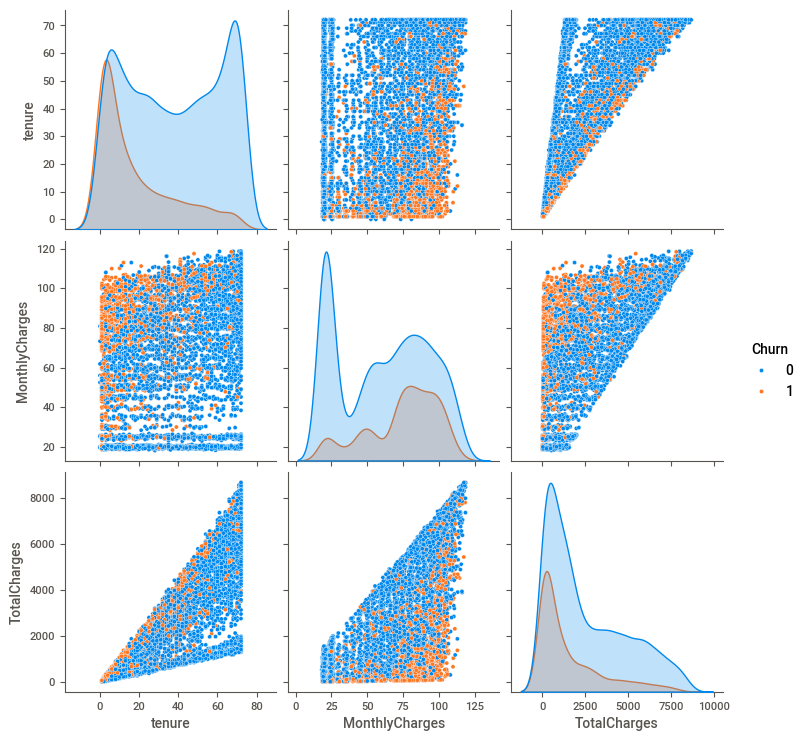

In [27]:
# رسم جفت نمودارها pairplot
sns.pairplot(numerical_features, hue="Churn")
plt.show()

## Categorical Analysis

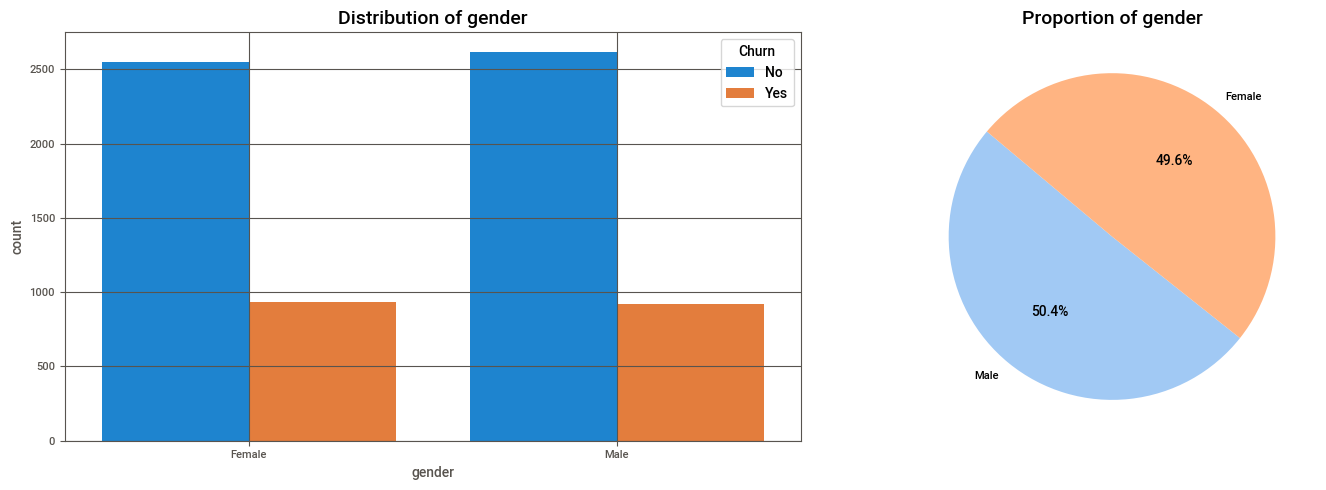

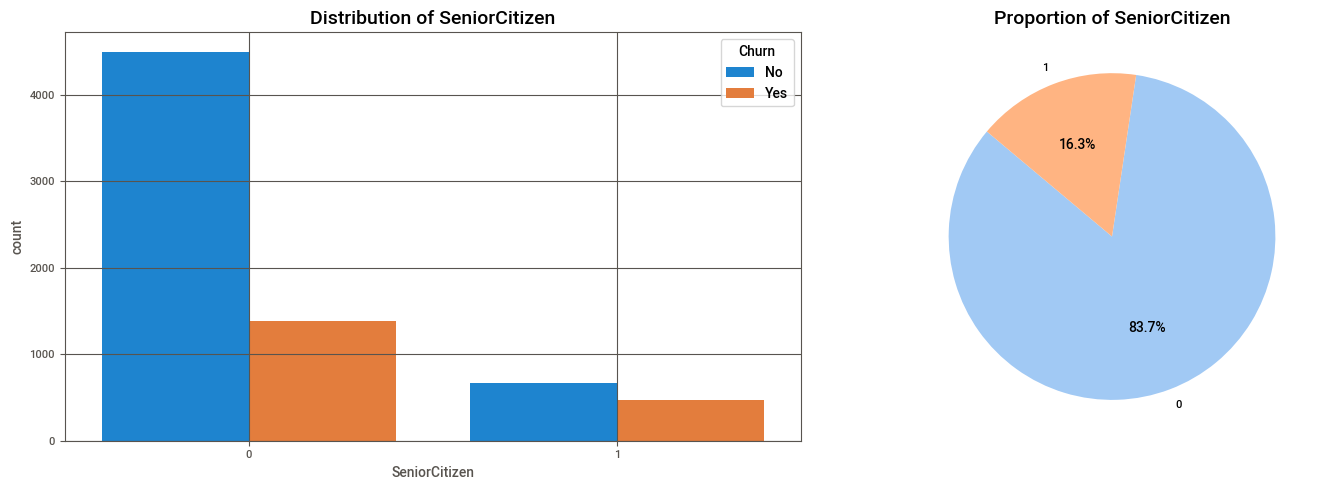

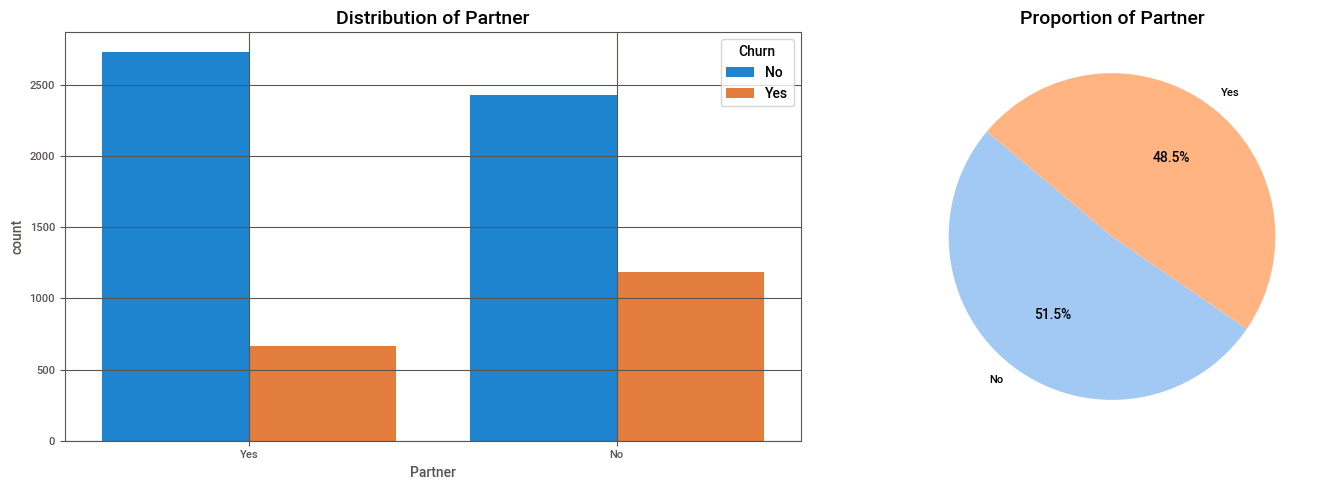

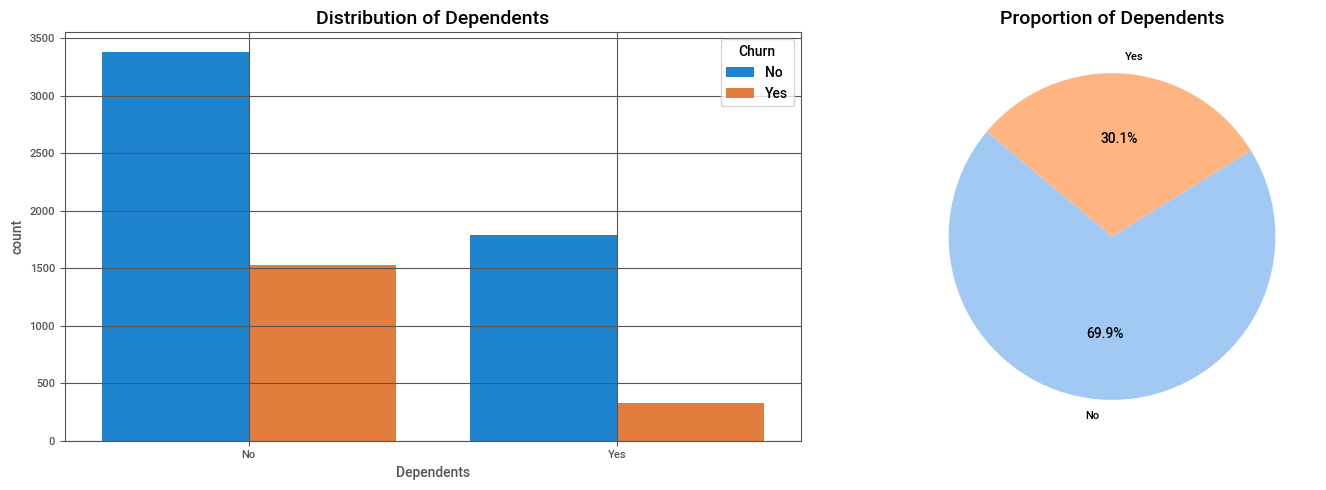

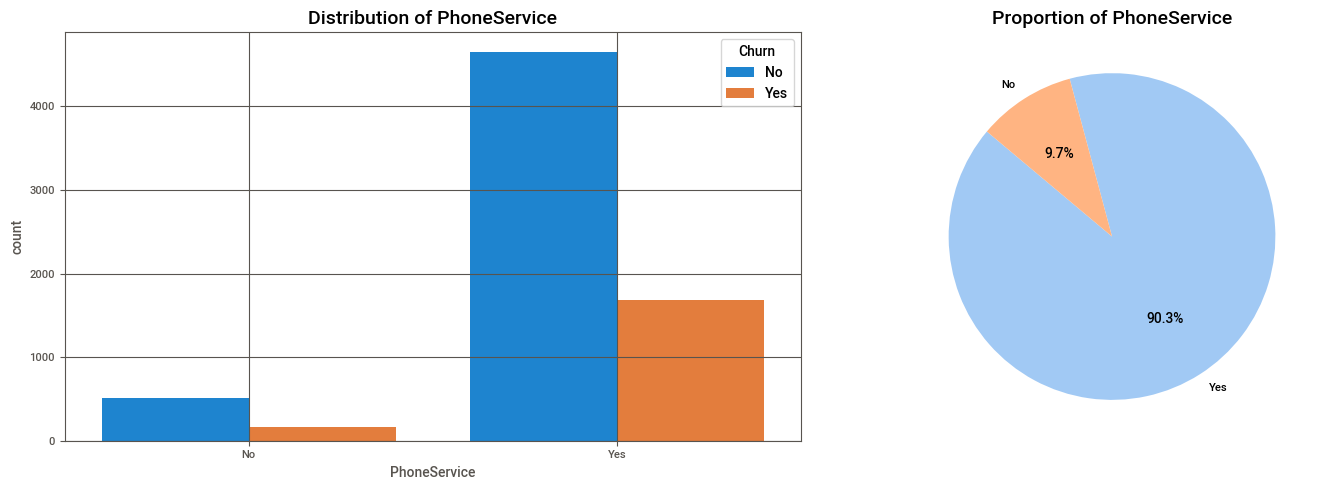

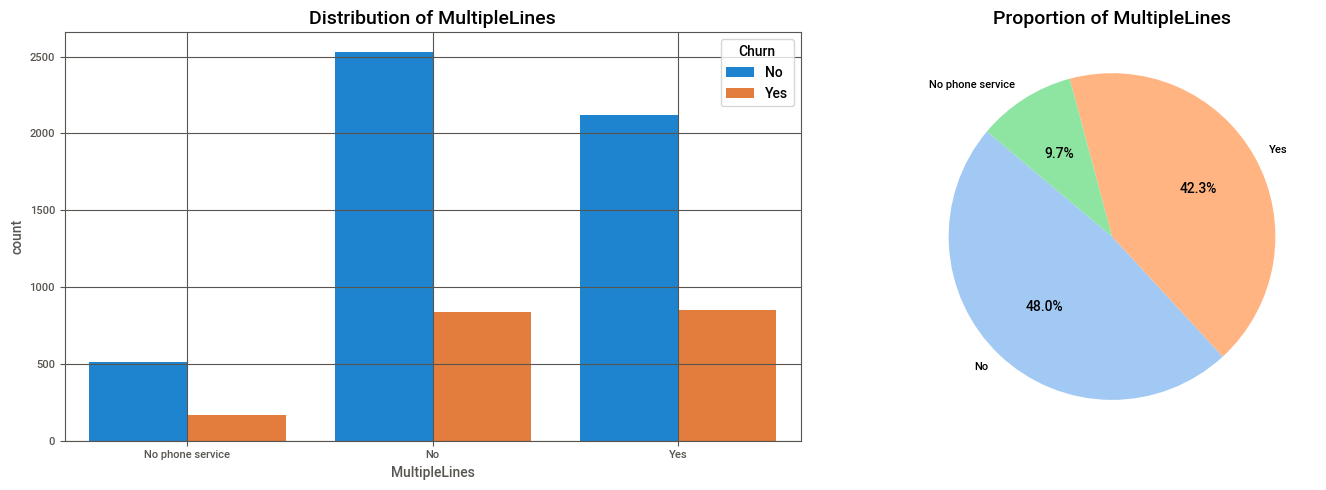

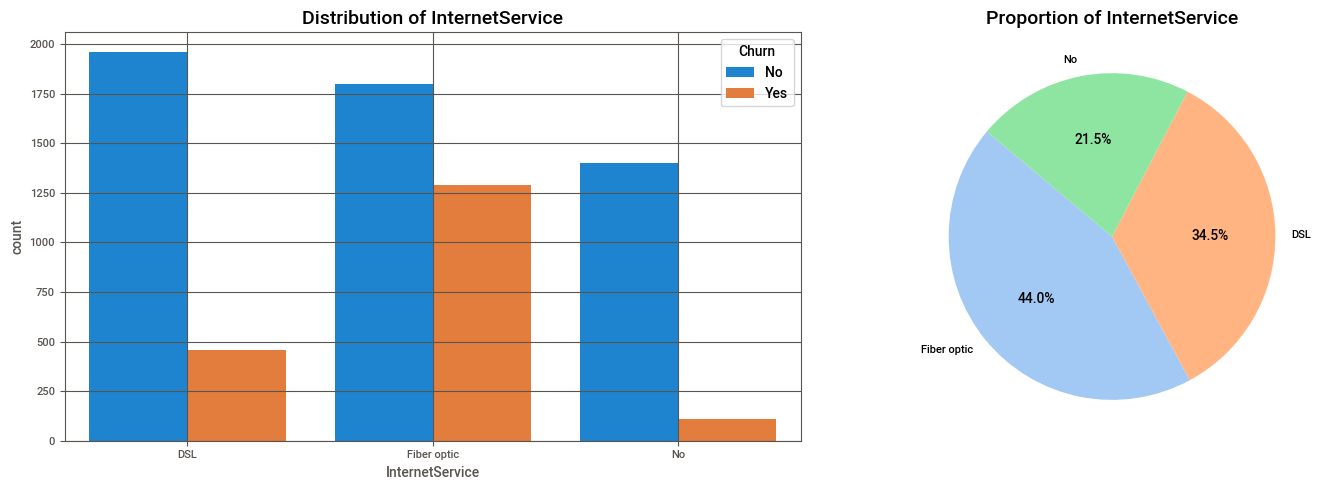

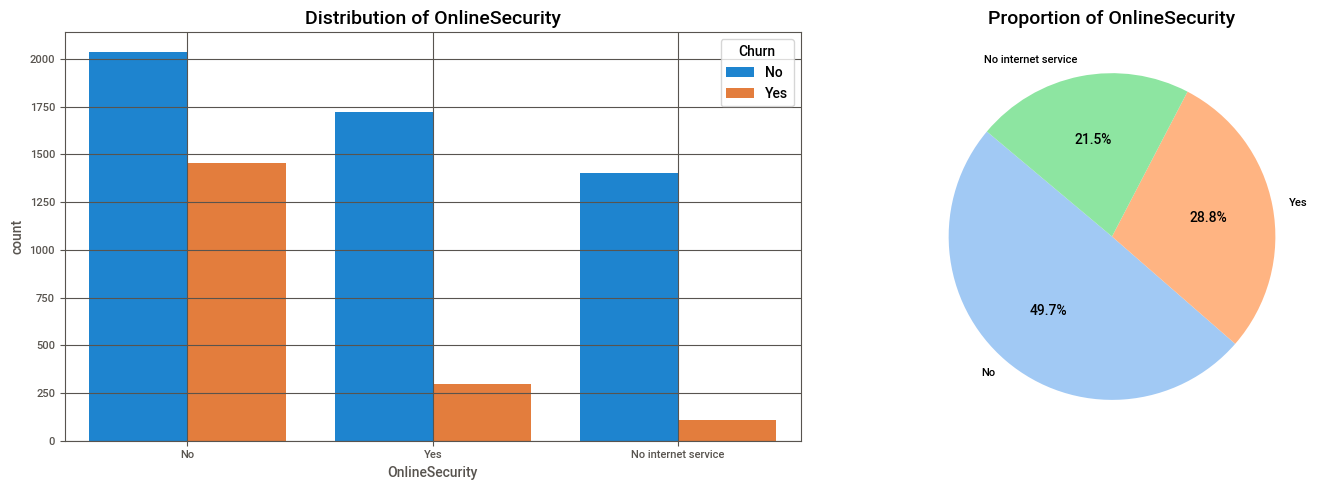

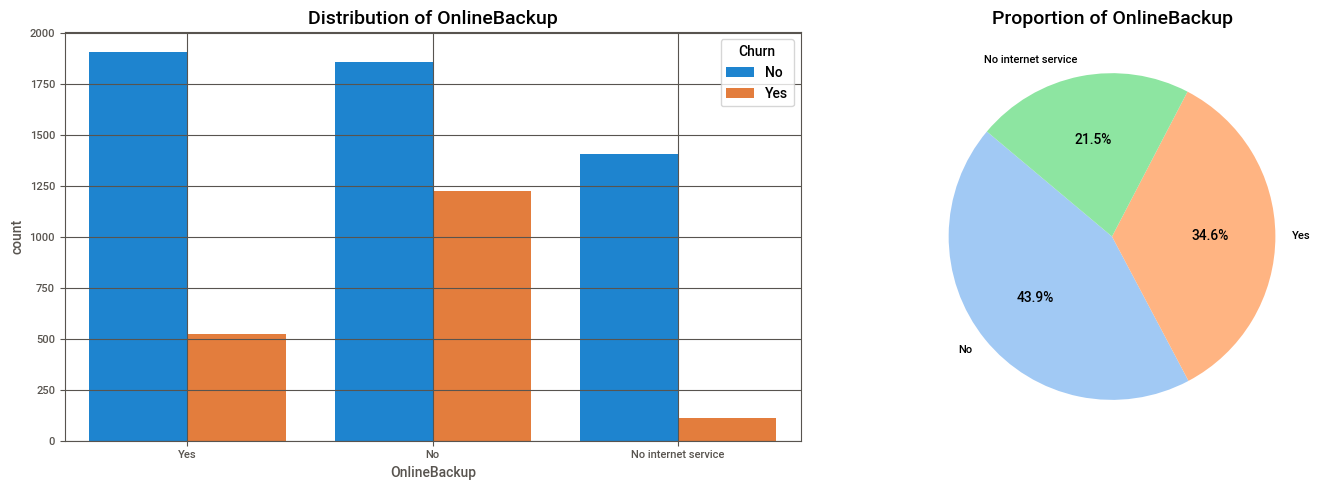

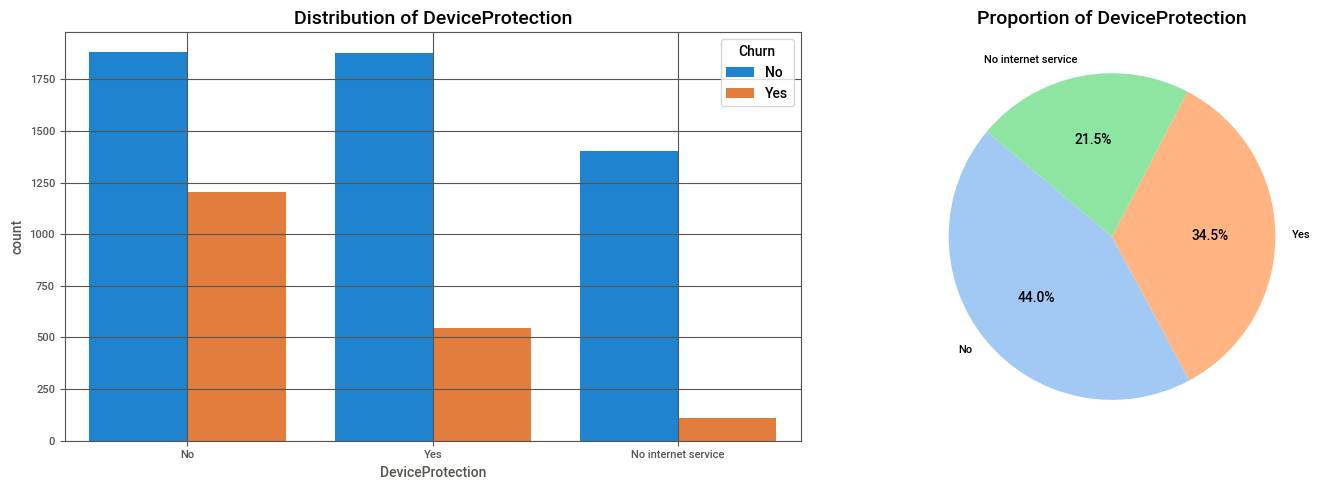

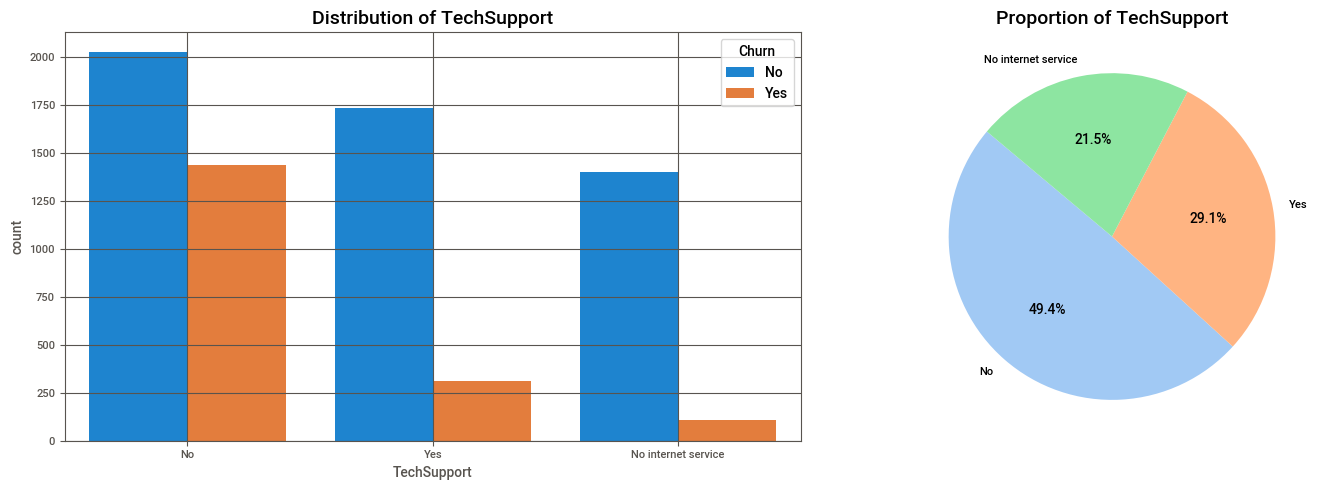

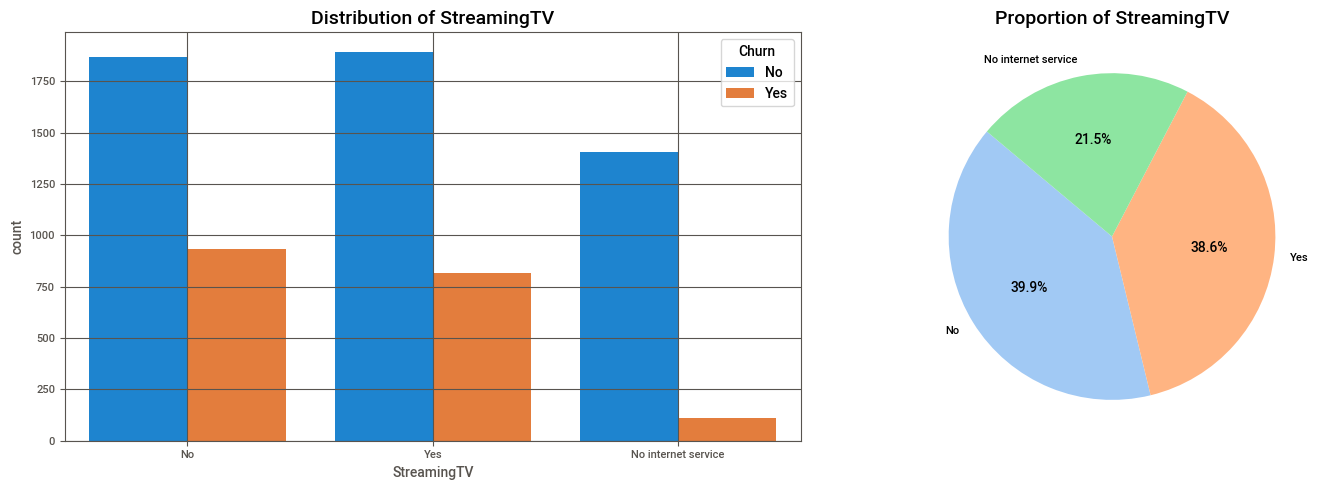

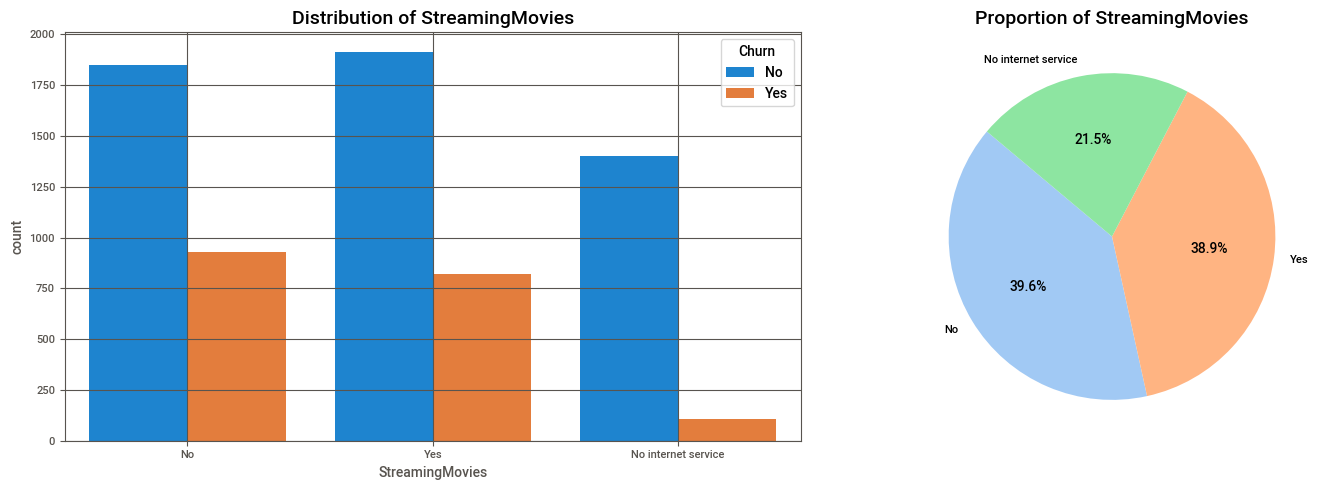

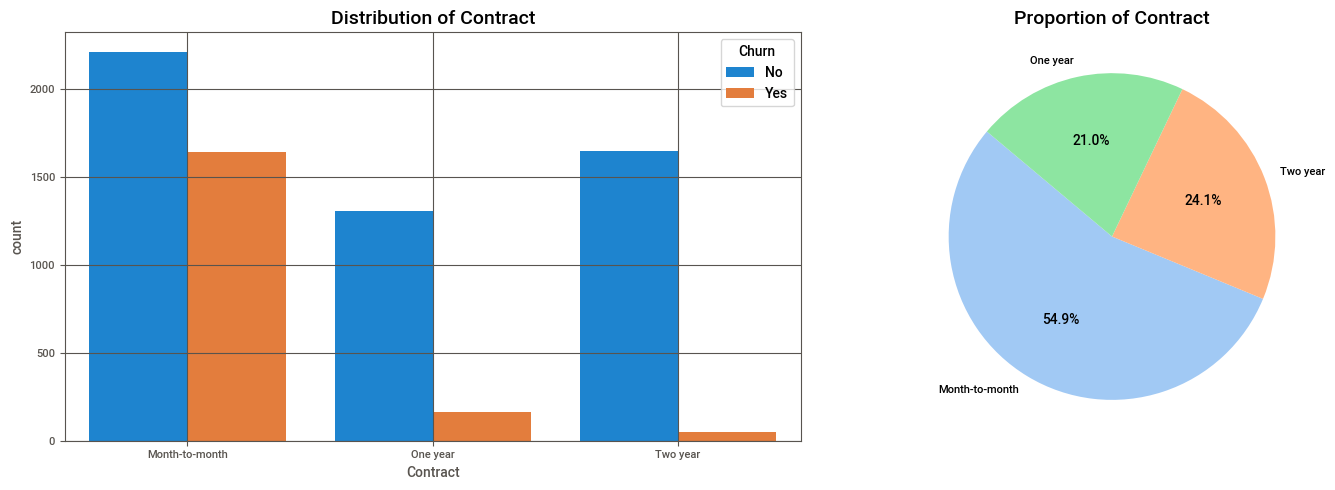

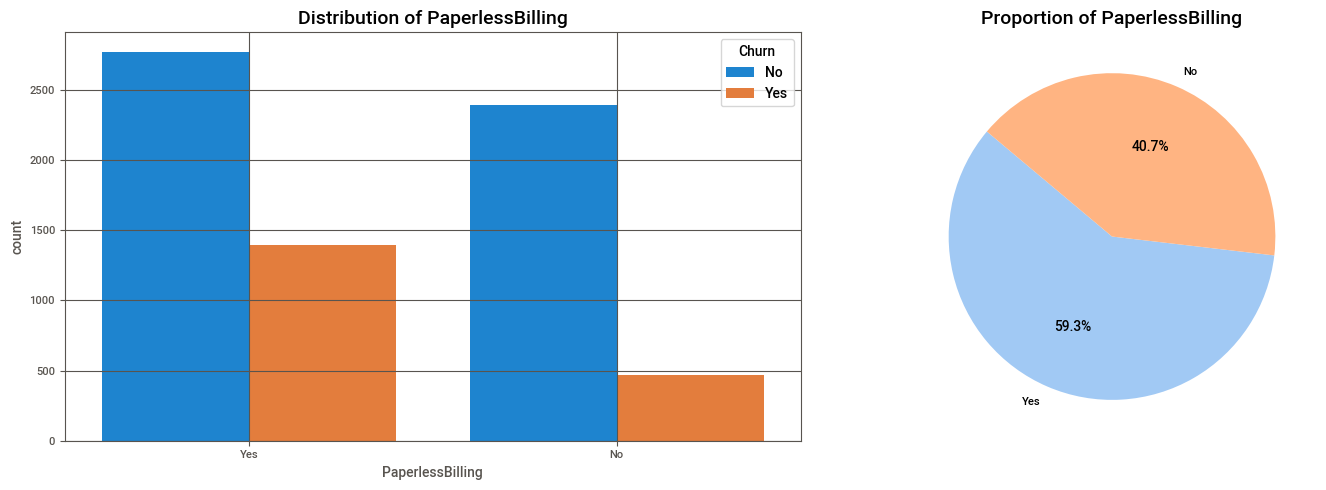

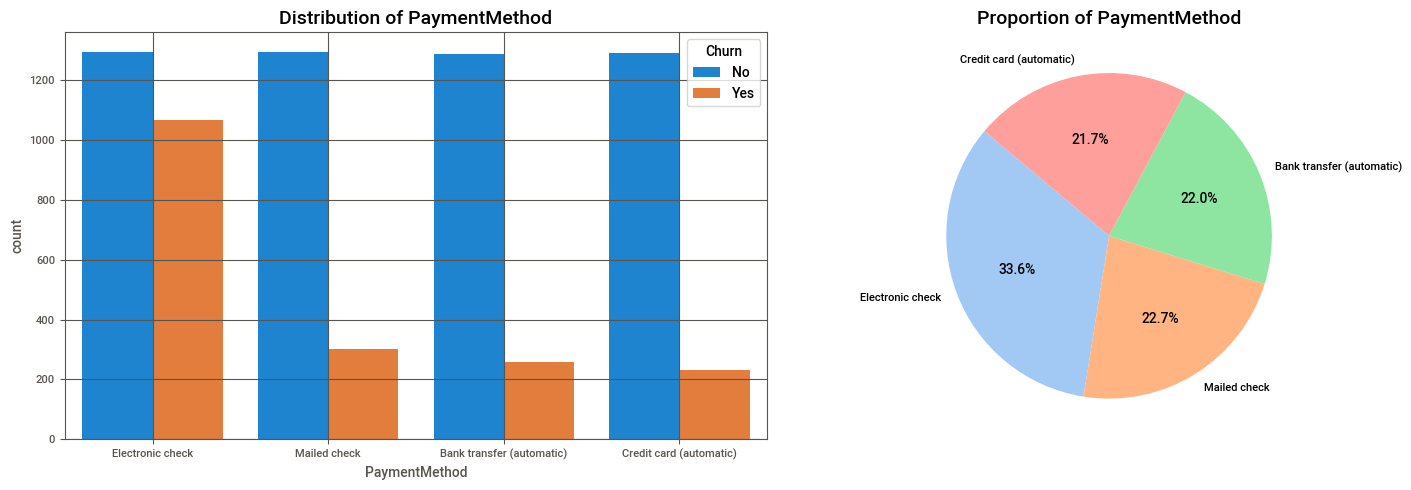

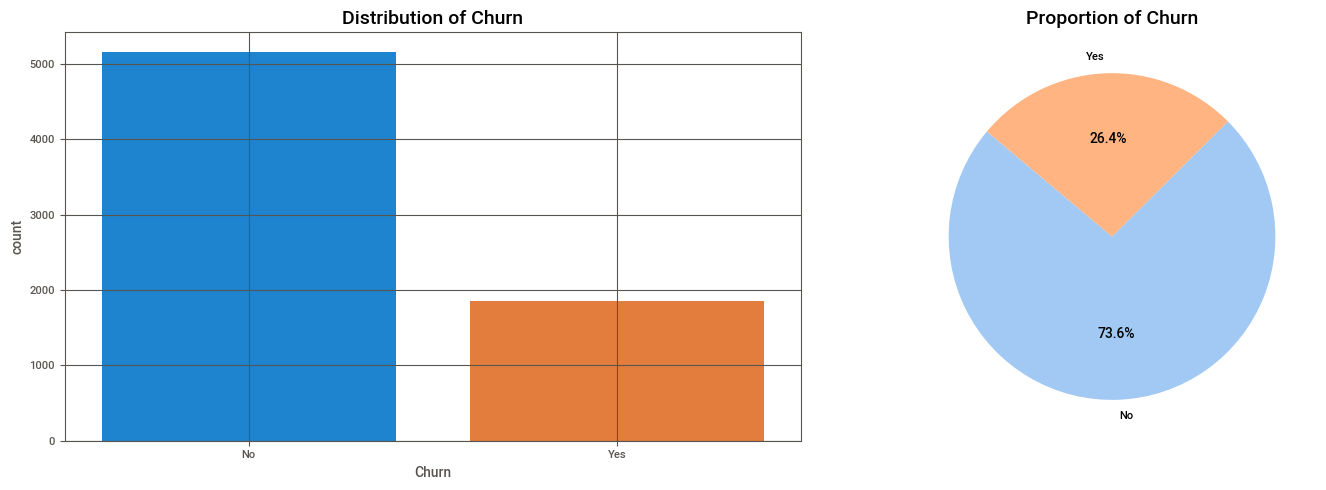

In [28]:
# تحلیل توزیع کلاس ها در ویژگی های دسته ای با استفاده از نمودار های CountPlot و PiePlot
for column in category_features.columns:

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # رسم نمودار CountPlot روی محور اول
    sns.countplot(data=category_features, x=column, hue="Churn", ax=axes[0])
    axes[0].set_title(f'Distribution of {column}', fontsize=14)
    axes[0].grid()

    counts = category_features[column].value_counts()
    
    # رسم نمودار PiePlot روی محور دوم
    axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    axes[1].set_title(f'Proportion of {column}', fontsize=14)
    
    # تنظیم فاصله و نمایش
    plt.tight_layout()
    plt.show()

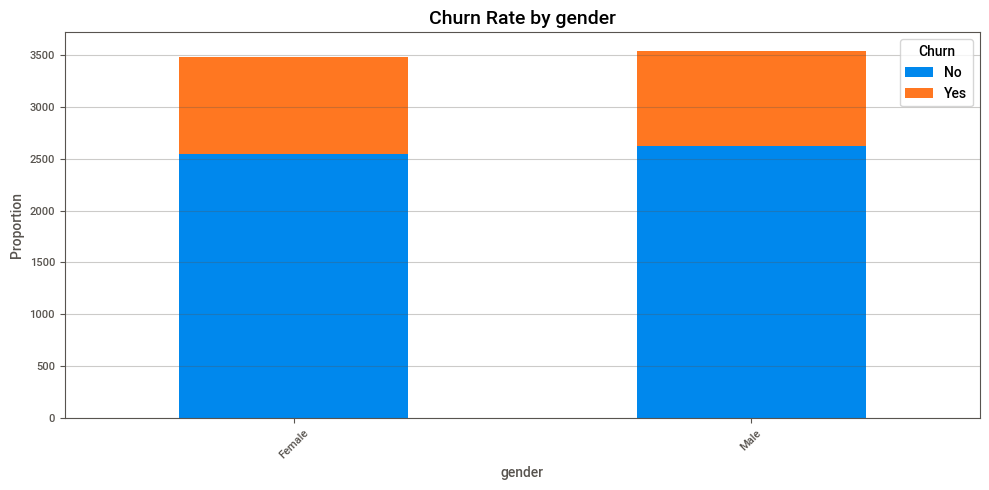

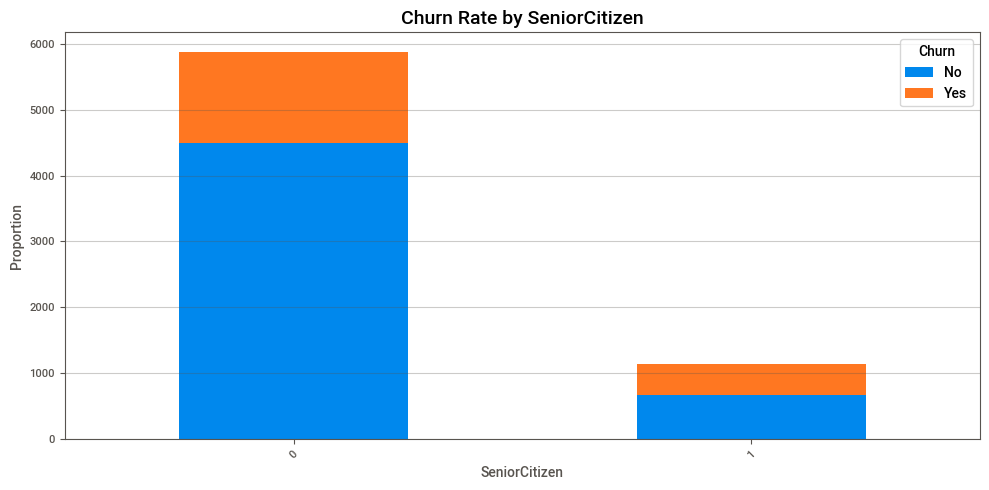

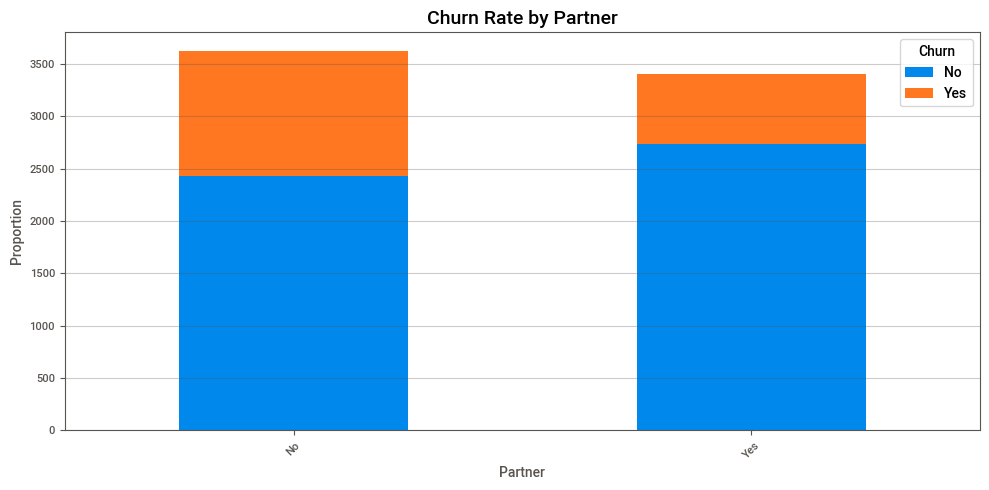

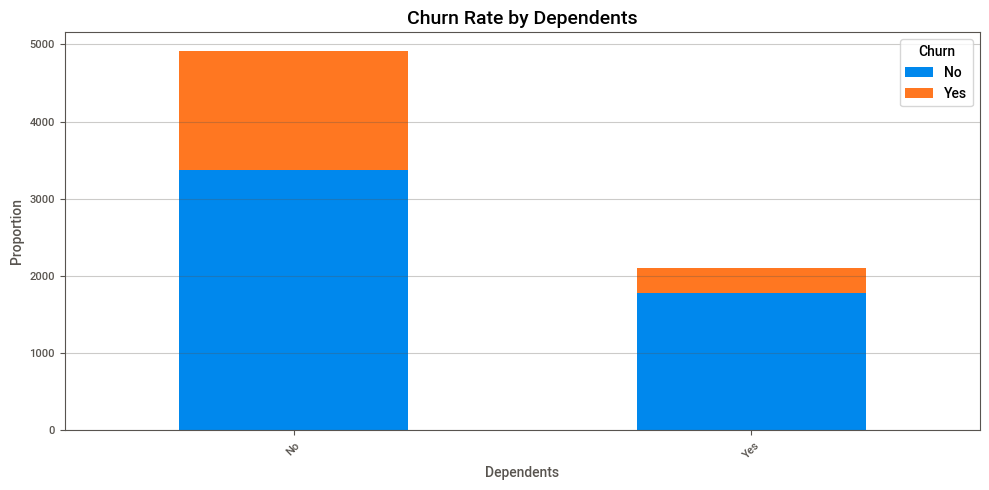

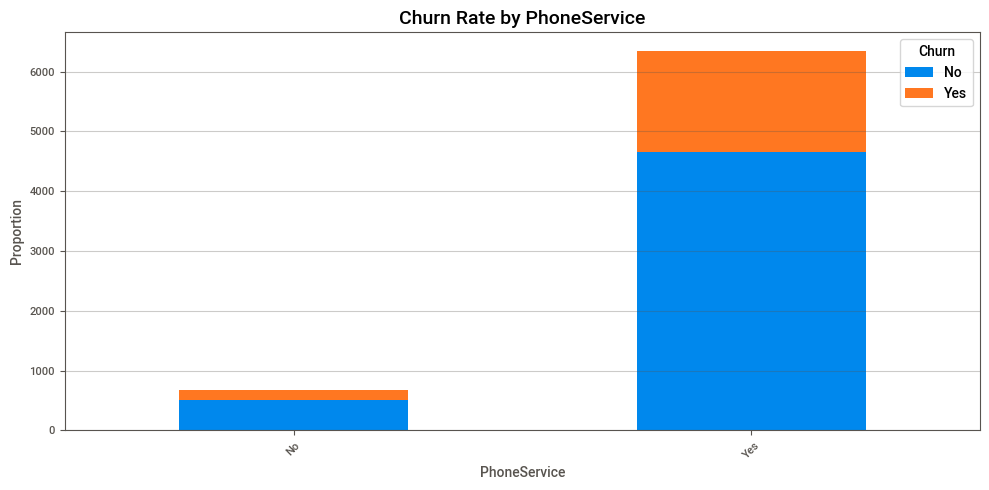

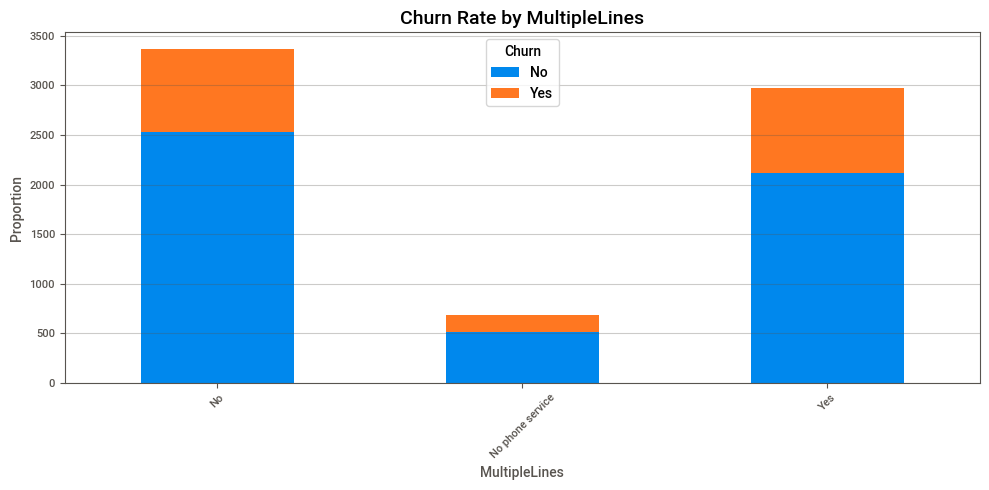

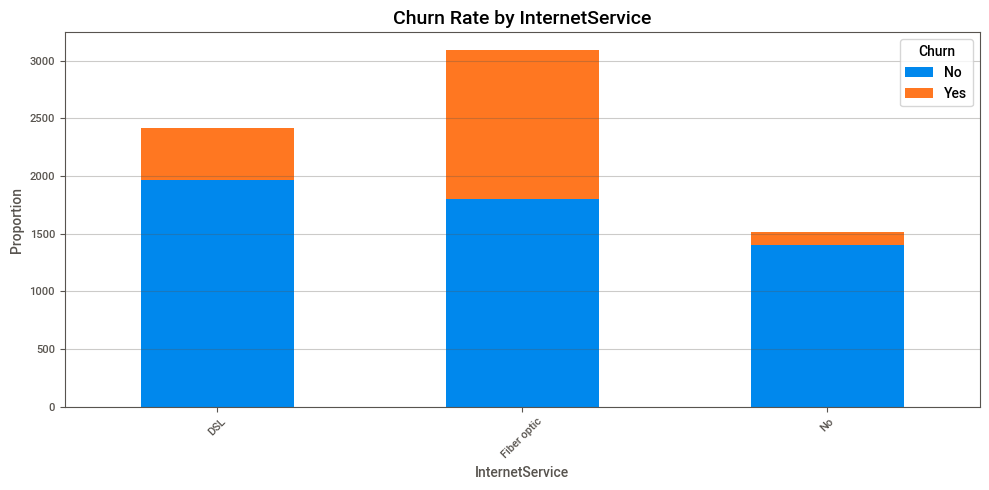

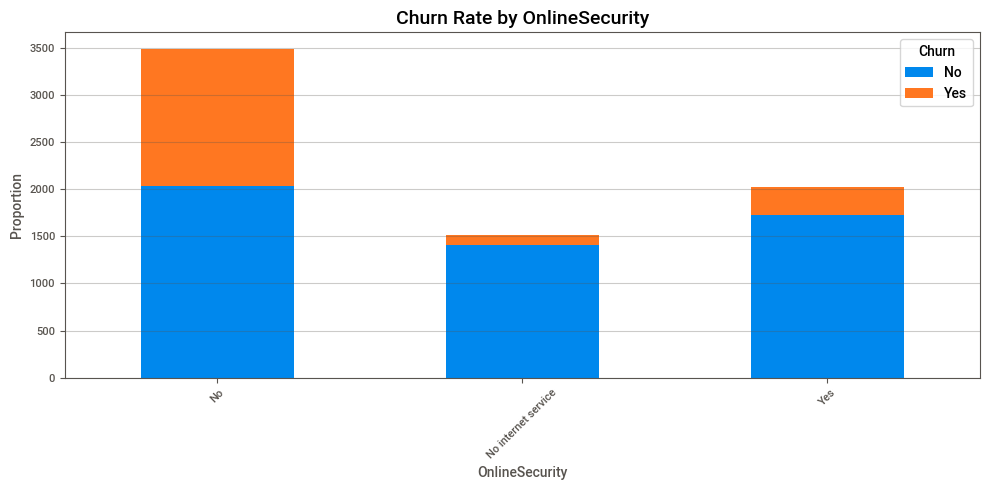

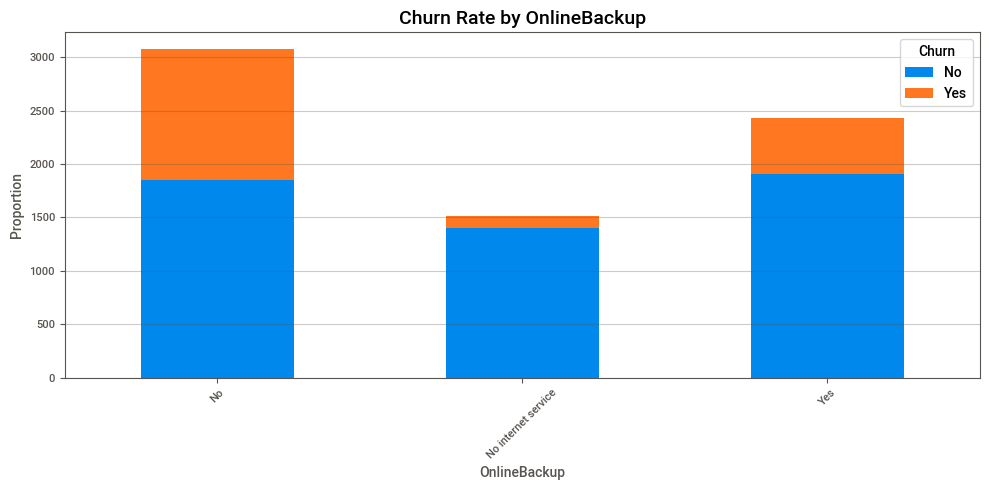

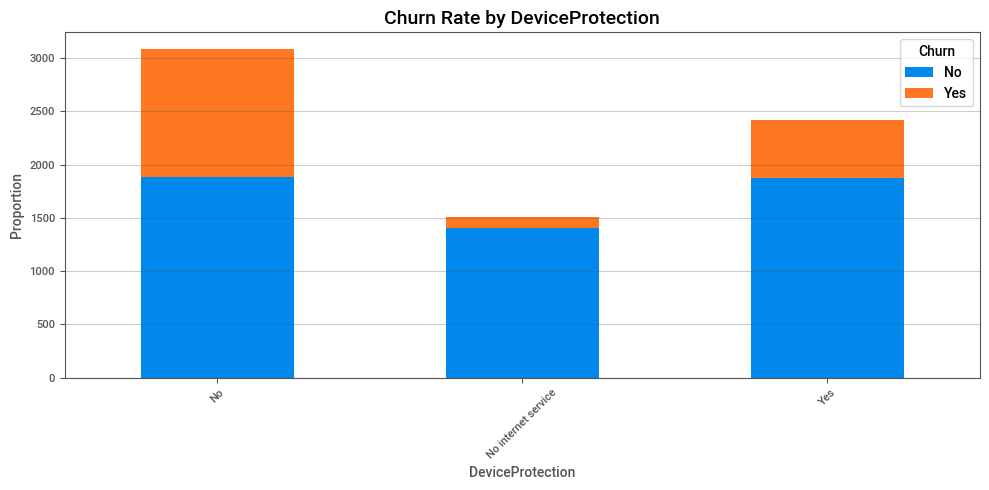

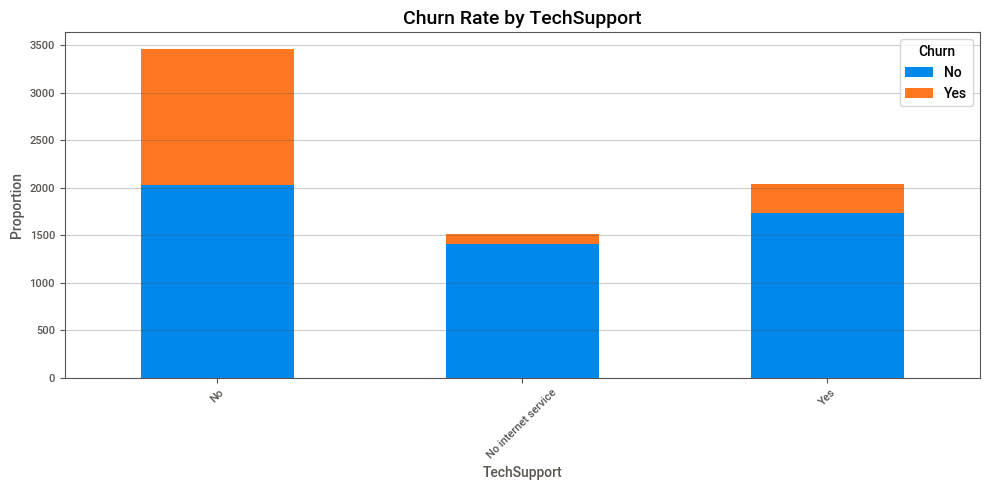

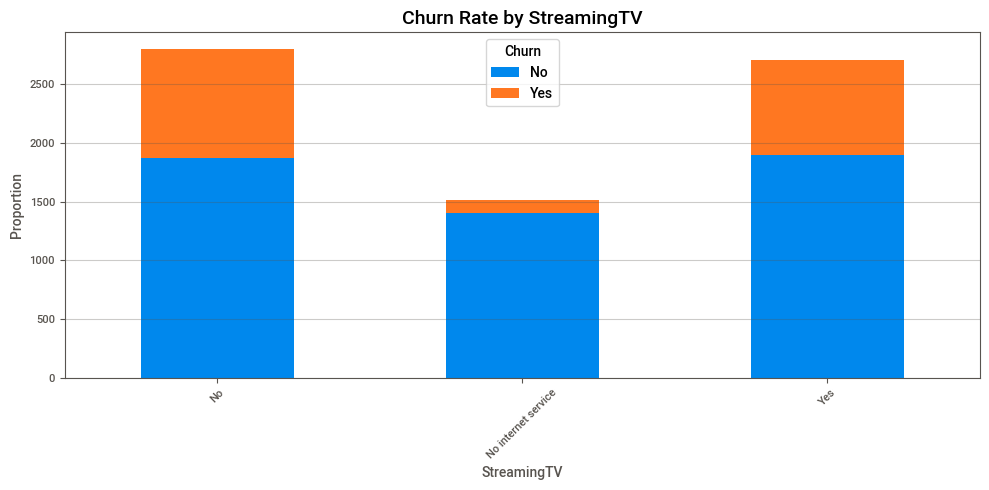

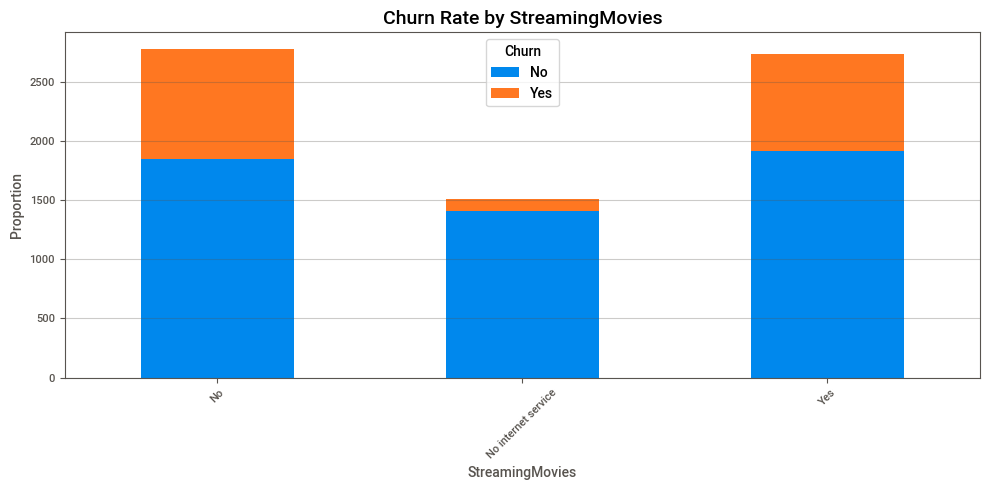

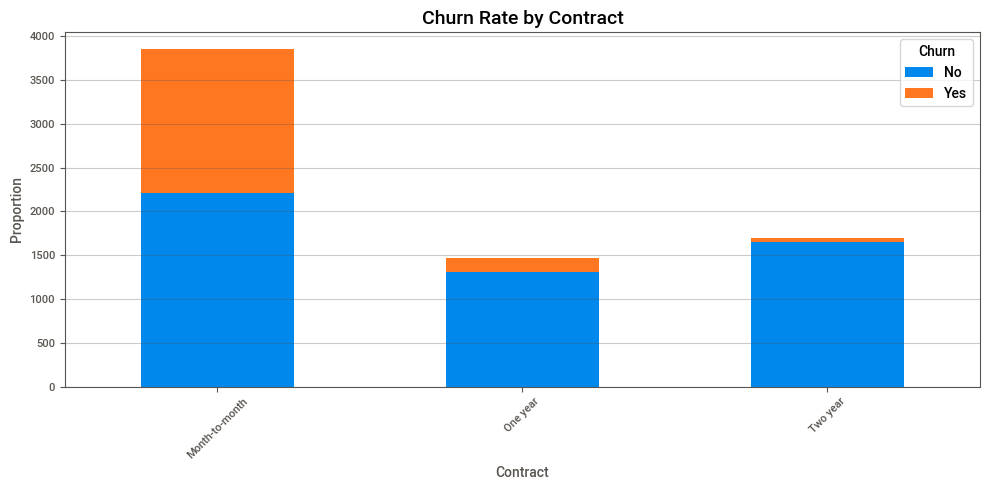

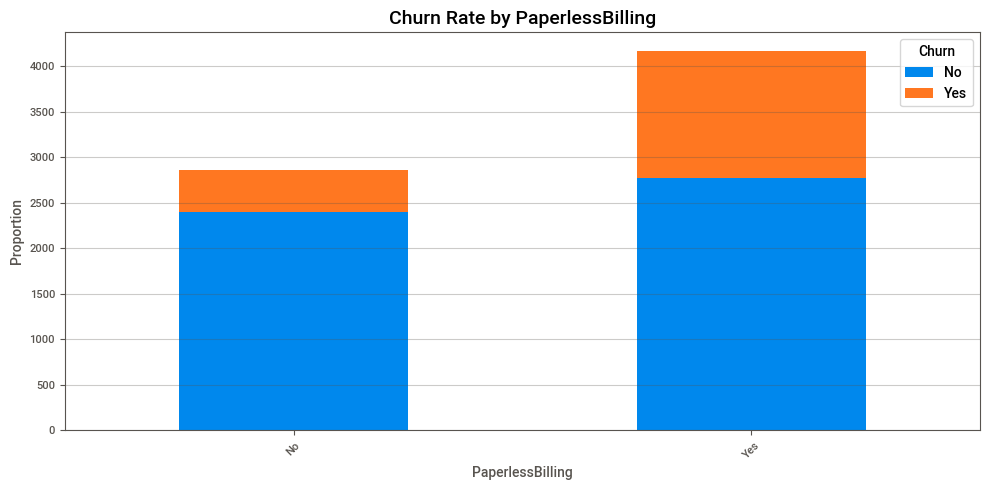

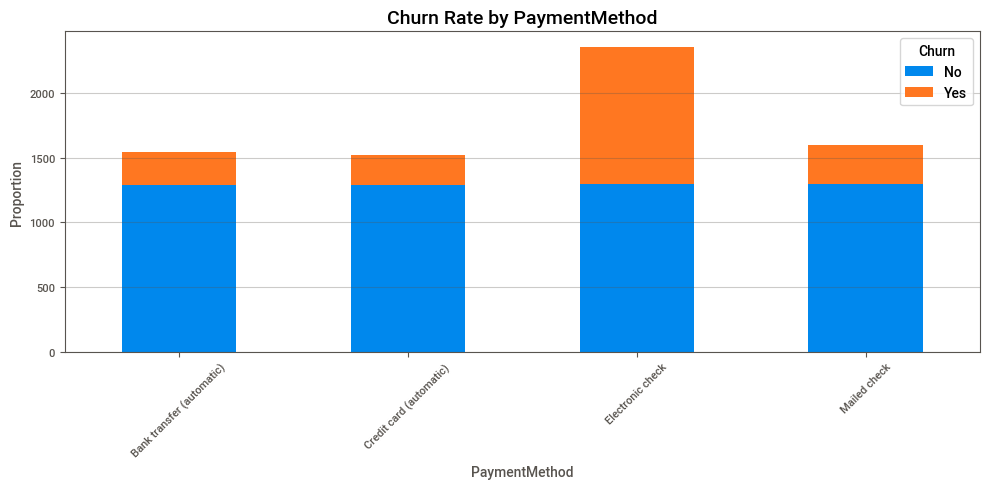

In [29]:
# نمایش توزیغ کلاس ها در ویژگی های دسته ای با استفاده از Stacked Bar Plot
for column in category_features.columns:
    if column == 'Churn':
        continue
    
    plt.figure(figsize=(10, 5))
    
    df_plot = pd.crosstab(category_features[column], category_features['Churn'])
    
    df_plot.plot(kind='bar', stacked=True, ax=plt.gca())
    
    plt.title(f'Churn Rate by {column}', fontsize=14)
    plt.ylabel('Proportion')
    plt.xlabel(column)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()

## Target Analysis

In [30]:
# بررسی توازن نمونه های متعلق به کلاس های 0 & 1
(df_customers["Churn"].value_counts() / len(df_customers)) * 100

Churn
No     73.550776
Yes    26.449224
Name: count, dtype: float64

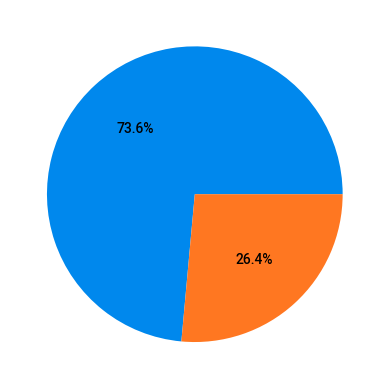

In [31]:
plt.pie(df_customers["Churn"].value_counts(), autopct='%1.1f%%')
plt.show()

In [32]:
# آماده سازی متغیر هدف Target
y = df_customers["Churn"].map({"No": 0, "Yes": 1}).values.reshape(-1)

In [33]:
# حذف متغیر هدف Target
X = df_customers.drop(columns="Churn")

In [34]:
# تعریف لیستی از ویژگی های عددی و دسته ای برای انجام مراحل پیش پردازش
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]

cat_features = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
                "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"]

In [35]:
warnings.filterwarnings("ignore")

In [36]:
# فراخوانی پیکیج های مورد نیاز برای مدل سازی
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,  roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

## Preprocessing Pipeline

In [37]:
# خط لوله پیش پردازش برای ویژگی های عددی (پر کردن مقادیر گمشده با استفاده از استراتژی میانه و استاندارد سازی ویژگی های عددی)
numeric_transform = Pipeline(steps=[
    ("missing_values", SimpleImputer(strategy='median')),
    ("standard_scaler", StandardScaler())
])

In [38]:
# خط لوله پیش پردازش برای ویژگی های دسته ای (پر کردن مقادیر گمشده با استفاده از استراتژی most_frequent و encode کردن ویژگی های دسته ای )
category_transform = Pipeline(steps=[
    ("missing_values", SimpleImputer(strategy='most_frequent')),
    ("one_hot_encoder", OneHotEncoder())
])

In [39]:
# انجام همزمان فرایند پیش پردازش روی ویژگی های عددی و دسته ای
preprocessor = ColumnTransformer(transformers=[
    ("num_transform", numeric_transform, num_features),
    ("cat_transform", category_transform, cat_features)
])

## Cross Validation

In [40]:
pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=1234)),
    ("classifier", LogisticRegression()),
])

# استفاده از StratifiedKFold با هدف تعادل نسبی کلاس ها در هر fold
stratify_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)

# انجام اعتبار سنجی با استفاده از cross validation
cross_validation = cross_validate(estimator=pipeline, X=X, y=y, verbose=10, cv=stratify_fold, scoring=["accuracy", "precision", "recall", "f1"])

[CV] START .....................................................................
[CV] END  accuracy: (test=0.761) f1: (test=0.632) precision: (test=0.533) recall: (test=0.774) total time=   3.4s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    3.4s


[CV] END  accuracy: (test=0.741) f1: (test=0.627) precision: (test=0.506) recall: (test=0.825) total time=   0.2s
[CV] START .....................................................................
[CV] END  accuracy: (test=0.753) f1: (test=0.630) precision: (test=0.521) recall: (test=0.798) total time=   0.2s
[CV] START .....................................................................
[CV] END  accuracy: (test=0.749) f1: (test=0.627) precision: (test=0.516) recall: (test=0.801) total time=   0.2s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    4.2s


[CV] END  accuracy: (test=0.764) f1: (test=0.637) precision: (test=0.538) recall: (test=0.780) total time=   0.2s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    4.5s finished


## Modeling Pipeline

In [41]:
# تعریف خط لوله ها برای پنج مدل طبقه بند (DTC, RFC, SVM, XGBOOST, CatBoost) برای مقایسه عملکردی
# هر مدل دارای انتخاب ویژگی با select from model و متعادل سازی داده ها با smote
pipelines = {
        "DTC": ImbPipeline(steps=[
            ("preprocessor", preprocessor),
            ("feature_selection", SelectFromModel(LogisticRegression(random_state=1234))),
            ("smote", SMOTE(random_state=1234)),
            ("DTClassifier", DecisionTreeClassifier(max_depth=5 ,random_state=1234)),
        ]),

        "RFC": ImbPipeline(steps=[
            ("preprocessor", preprocessor),
            ("feature_selection", SelectFromModel(LogisticRegression(random_state=1234))),
            ("smote", SMOTE(random_state=1234)),
            ("RFClassifier", RandomForestClassifier(max_depth=5 ,random_state=1234)),
        ]),

        "SVM": ImbPipeline(steps=[
            ("preprocessor", preprocessor),
            ("feature_selection", SelectFromModel(LogisticRegression(random_state=1234))),
            ("smote", SMOTE(random_state=1234)),
            ("SVClassifier", SVC(probability=True, random_state=1234)),
        ]),

        "XGBoost": ImbPipeline(steps=[
            ("preprocessor", preprocessor),
            ("feature_selection", SelectFromModel(LogisticRegression(random_state=1234))),
            ("smote", SMOTE(random_state=1234)),
            ("XGBoostClassifier", XGBClassifier(max_depth=5, learning_rate=0.01, random_state=1234)),
        ]),
    
        "CatBoost": ImbPipeline(steps=[
            ("preprocessor", preprocessor),
            ("feature_selection", SelectFromModel(LogisticRegression(random_state=1234))),
            ("smote", SMOTE(random_state=1234)),
            ("CatBoostClassifier", CatBoostClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=1234)),
        ]),
}

In [42]:
# تفکیک داده های آموزشی train و آزمون test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=1234)

## Training & Evaluation

In [43]:
result_train = {}
result_test = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_predict_train = pipe.predict(X_train)
    y_predict_test = pipe.predict(X_test)

    y_proba_train = pipe.predict_proba(X_train)[:, 1]
    y_proba_test = pipe.predict_proba(X_test)[:, 1]

    result_train[name] = {
        "accuracy_train": accuracy_score(y_train, y_predict_train),
        "precision_train": precision_score(y_train, y_predict_train),
        "recall_train": recall_score(y_train, y_predict_train),
        "f1_train": f1_score(y_train, y_predict_train),
        "auc_train": roc_auc_score(y_train, y_proba_train),
    }

    result_test[name] = {
        "accuracy_test": accuracy_score(y_test, y_predict_test),
        "precision_test": precision_score(y_test, y_predict_test),
        "recall_test": recall_score(y_test, y_predict_test),
        "f1_test": f1_score(y_test, y_predict_test),
        "auc_test": roc_auc_score(y_test, y_proba_test),
    }

0:	learn: 0.6621092	total: 166ms	remaining: 16.5s
1:	learn: 0.6385796	total: 171ms	remaining: 8.39s
2:	learn: 0.6171085	total: 176ms	remaining: 5.71s
3:	learn: 0.5985276	total: 180ms	remaining: 4.32s
4:	learn: 0.5836307	total: 184ms	remaining: 3.49s
5:	learn: 0.5706647	total: 188ms	remaining: 2.94s
6:	learn: 0.5596479	total: 192ms	remaining: 2.55s
7:	learn: 0.5502258	total: 196ms	remaining: 2.25s
8:	learn: 0.5415584	total: 201ms	remaining: 2.03s
9:	learn: 0.5346508	total: 205ms	remaining: 1.84s
10:	learn: 0.5279446	total: 209ms	remaining: 1.69s
11:	learn: 0.5222524	total: 212ms	remaining: 1.56s
12:	learn: 0.5170949	total: 216ms	remaining: 1.45s
13:	learn: 0.5128995	total: 220ms	remaining: 1.35s
14:	learn: 0.5077080	total: 224ms	remaining: 1.27s
15:	learn: 0.5039281	total: 229ms	remaining: 1.2s
16:	learn: 0.5007151	total: 234ms	remaining: 1.14s
17:	learn: 0.4976973	total: 239ms	remaining: 1.09s
18:	learn: 0.4946909	total: 244ms	remaining: 1.04s
19:	learn: 0.4916578	total: 249ms	remainin

## Analysis Of Models Evaluation Results

In [44]:
# تبدیل نتایج train و test به DataFrame
results_train = pd.DataFrame(result_train).T
results_test = pd.DataFrame(result_test).T

In [45]:
results_train

,accuracy_train,precision_train,recall_train,f1_train,auc_train
DTC,0.713675,0.477512,0.873846,0.617559,0.846054
RFC,0.760073,0.530633,0.806154,0.640000,0.857581
SVM,0.755596,0.525398,0.787692,0.630348,0.844403
XGBoost,0.760480,0.530765,0.816154,0.643225,0.861199
CatBoost,0.761091,0.532045,0.804615,0.640539,0.862491


In [46]:
results_test

,accuracy_test,precision_test,recall_test,f1_test,auc_test
DTC,0.708590,0.471921,0.859964,0.609415,0.832743
RFC,0.745610,0.512281,0.786355,0.620397,0.838330
SVM,0.743237,0.509368,0.780969,0.616584,0.811648
XGBoost,0.740864,0.506403,0.780969,0.614407,0.834672
CatBoost,0.743237,0.509346,0.782765,0.617127,0.836852


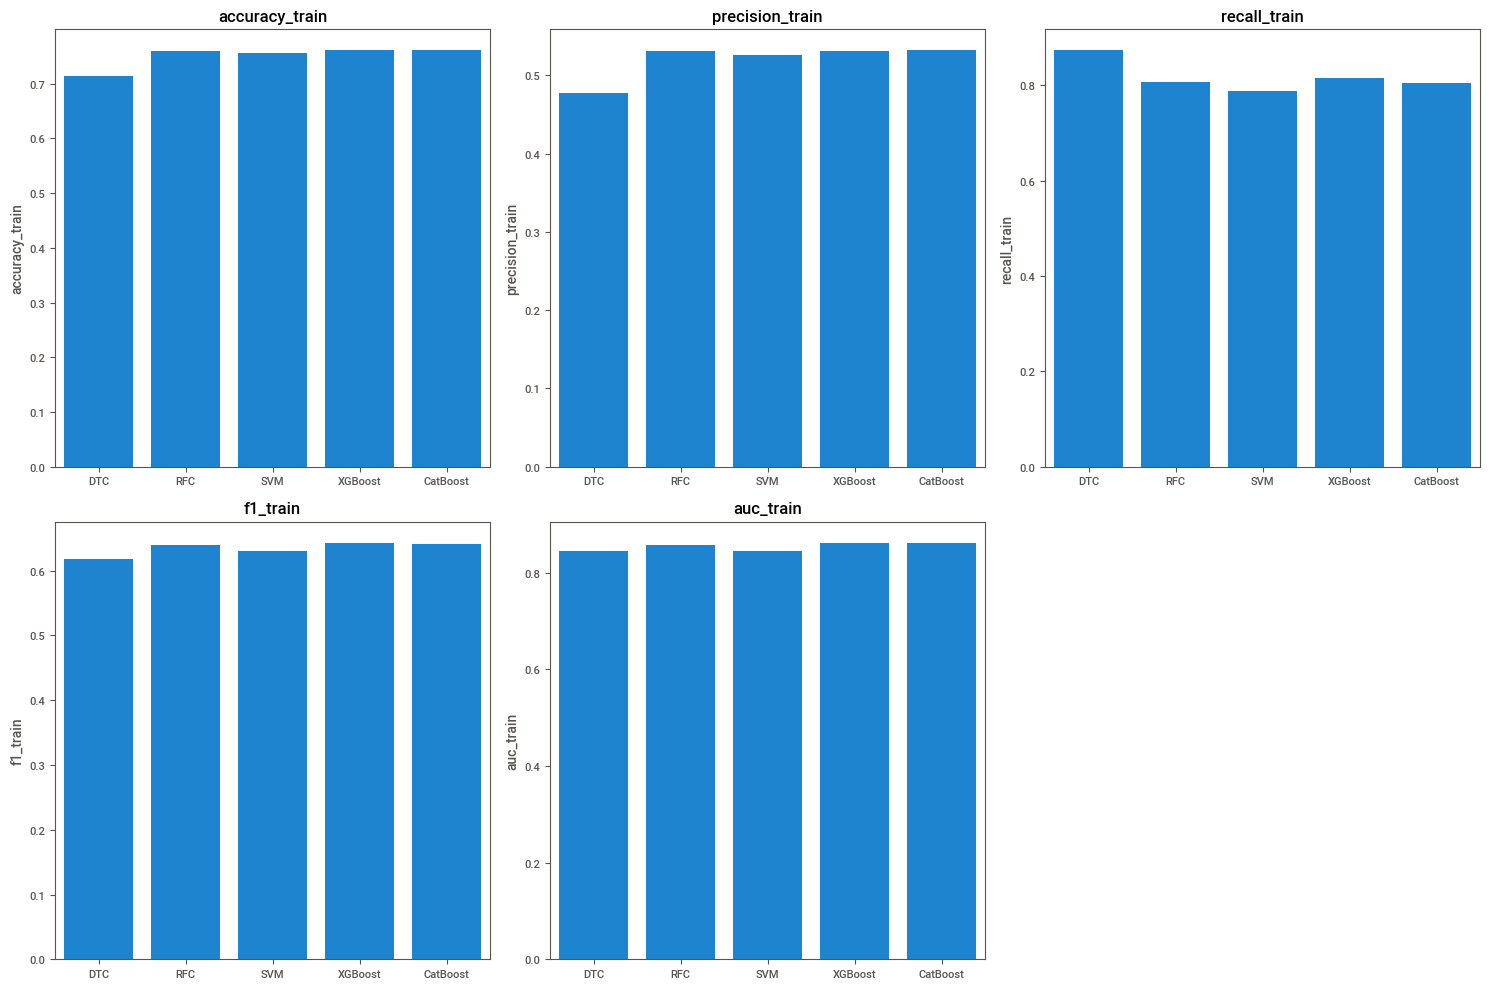

In [47]:
# رسم نمودارهای ستونی برای مقایسه عملکرد مدل‌ها در داده‌های آموزش و تست
n_cols = 3
n_rows = (len(results_train) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, column in enumerate(results_train):
    sns.barplot(results_train[column], ax=axes[i])
    axes[i].set_title(column)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

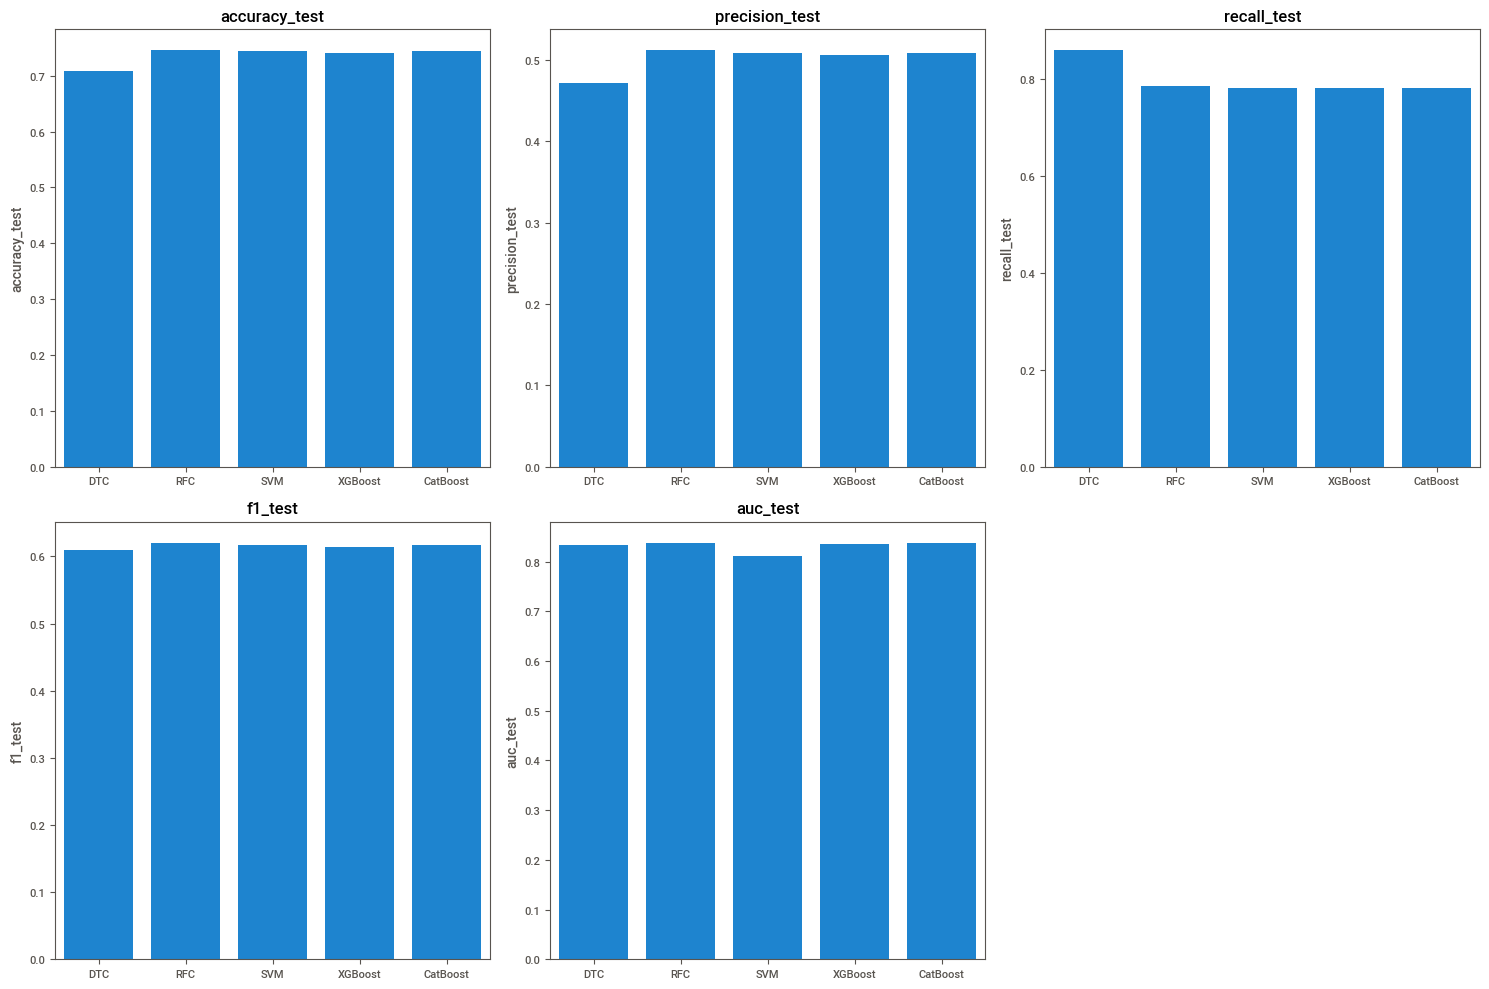

In [48]:
n_cols = 3
n_rows = (len(results_test) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, column in enumerate(results_test):
    sns.barplot(results_test[column], ax=axes[i])
    axes[i].set_title(column)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Assessing The Importance Of Features

In [49]:
model_names = list(pipelines.keys())

In [50]:
all_importance_results = []

In [51]:
for name in model_names:
    current_pipeline = pipelines[name]
    
    # محاسبه میزان اهمیت ویژگی ها با استفاده از permutation_importance
    result = permutation_importance(
        current_pipeline, X_test, y_test, 
        n_repeats=5,
        random_state=1234,
        n_jobs=-1
    )

    # دریافت نام ویژگی ها از دیتاست test
    feature_names = X_test.columns

    # ذخیره نتایج اهمیت ویژگی ها از نظر مدل ها
    model_df = pd.DataFrame({
        'Model': name,
        'Feature': feature_names,
        'Importance_Mean': result.importances_mean,
    })

    all_importance_results.append(model_df)

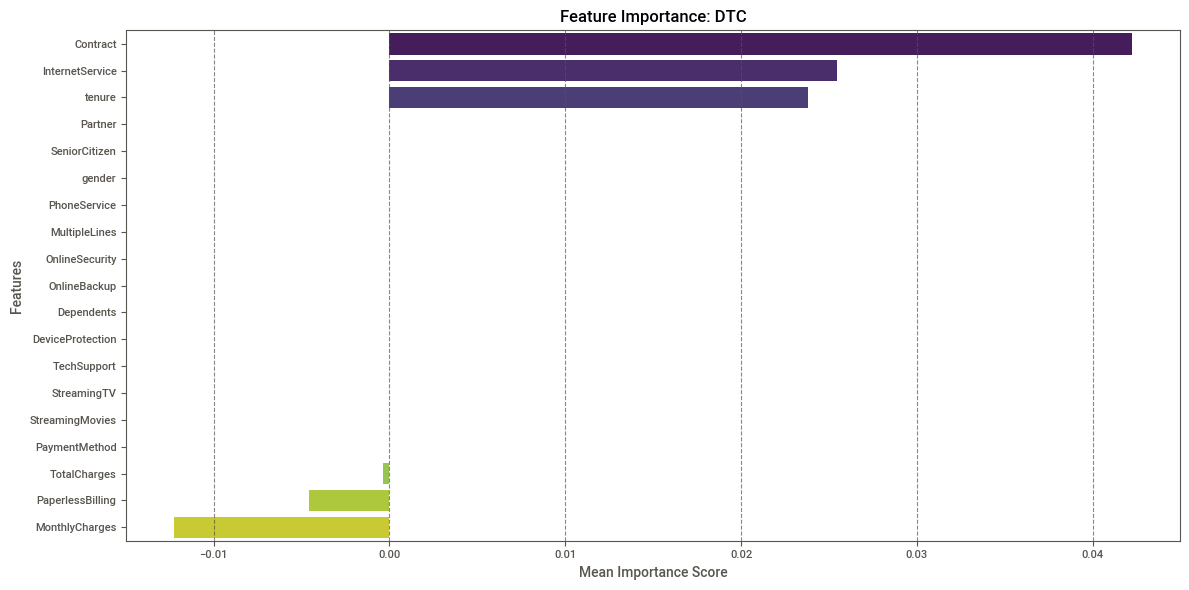

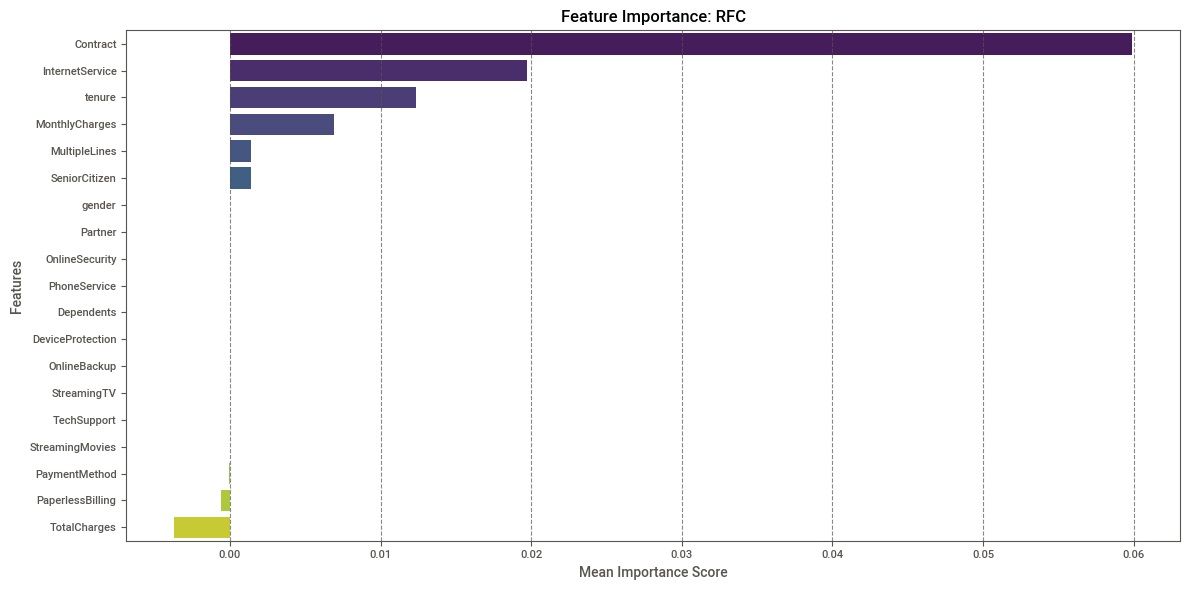

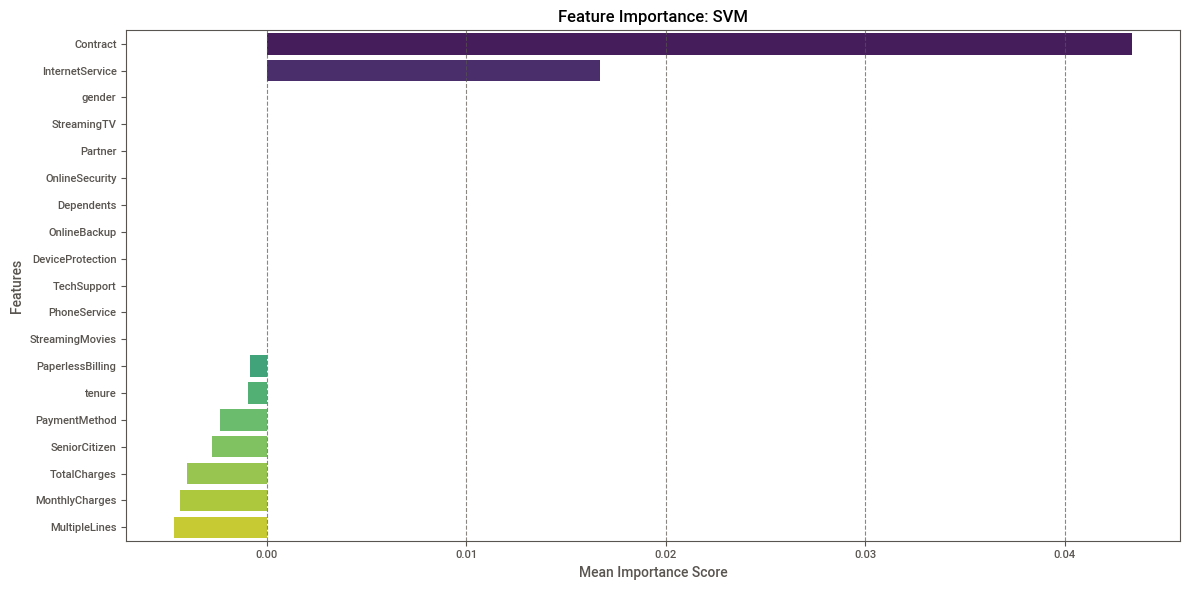

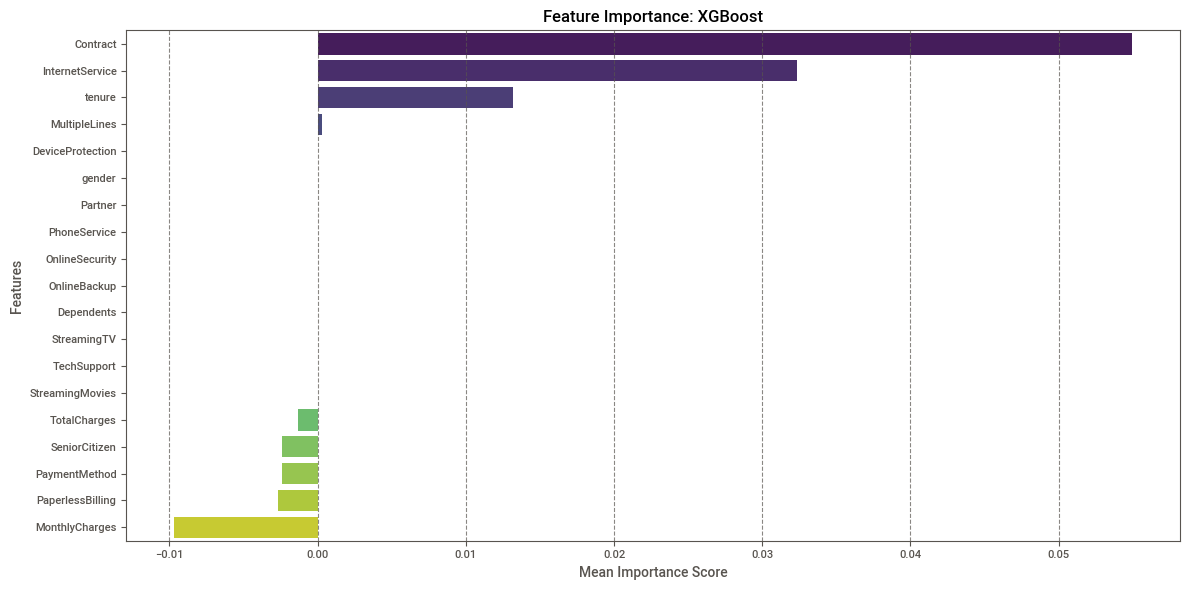

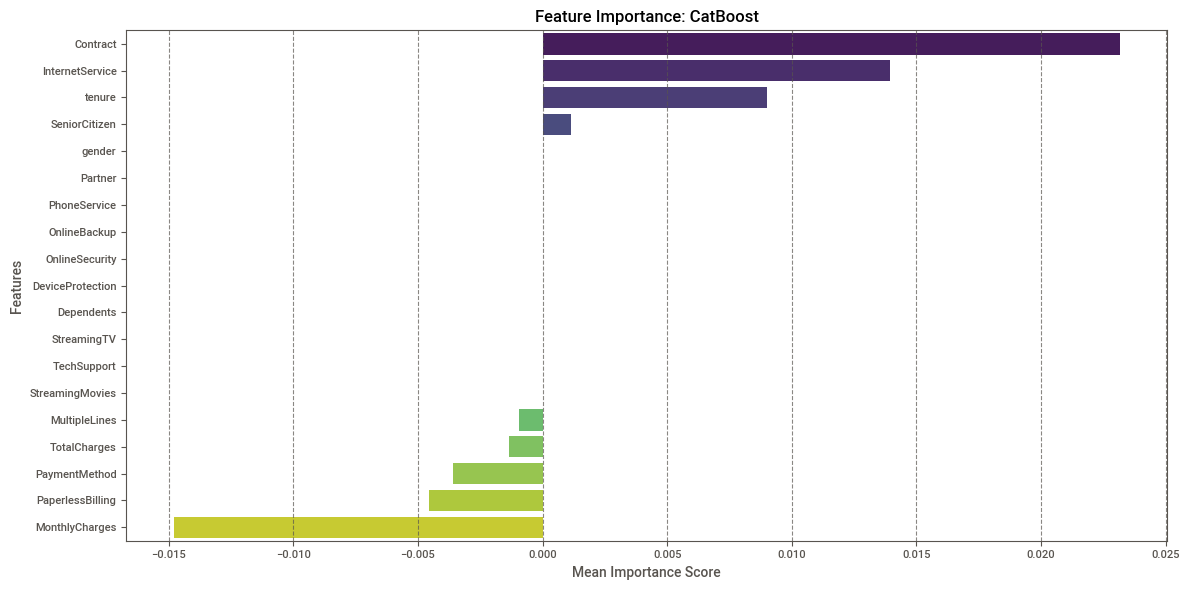

In [52]:
for model in all_importance_results:
    # مرتب‌سازی ویژگی‌ها بر اساس بیشترین اهمیت برای خوانایی بهتر نمودار
    df_sorted = model.sort_values(by='Importance_Mean', ascending=False)

    plt.figure(figsize=(12, 6))

    # رسم نمودار barplot برای نمایش میزان اهمیت و تاثیر گزاری ویژگی ها روی تصمیم گیری مدل
    sns.barplot(x="Importance_Mean", y="Feature", data=df_sorted, palette="viridis")

    plt.title(f"Feature Importance: {df_sorted['Model'].iloc[0]}")
    plt.xlabel("Mean Importance Score")
    plt.ylabel("Features")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Investigating the Impact of Feature Behavior on Model Prediction

In [53]:
# استخراج مراحل پیش پردازش انتخاب ویژگی و مدل سازی از داخل پایت لاین
preprocessor = pipelines["RFC"].named_steps["preprocessor"]
selector = pipelines["RFC"].named_steps["feature_selection"]
estimator = pipelines["RFC"] .named_steps["RFClassifier"]

In [54]:
# دریافت نام تمام ستون‌های تولید شده توسط پیش‌پردازشگر خط لوله
new_feature_names = preprocessor.get_feature_names_out()
# پیدا کردن ایندکس ستون‌هایی که توسط مرحله انتخاب ویژگی تایید شده‌اند
selected_indices = selector.get_support(indices=True)
# فیلتر کردن نام ستون‌های اصلی بر اساس ستون‌های انتخاب شده
# در نهایت فقط نام ستون‌هایی را داریم که واقعاً وارد مدل شده‌اند
feature_names = [new_feature_names[i] for i in selected_indices]

In [55]:
# اعمال فرایند پیش پردازش روی داده های test
X_preprocess = preprocessor.transform(X_test)
# اعمال فرایند انتخاب ویژگی روی داده های test
X_selector = selector.transform(X_preprocess)

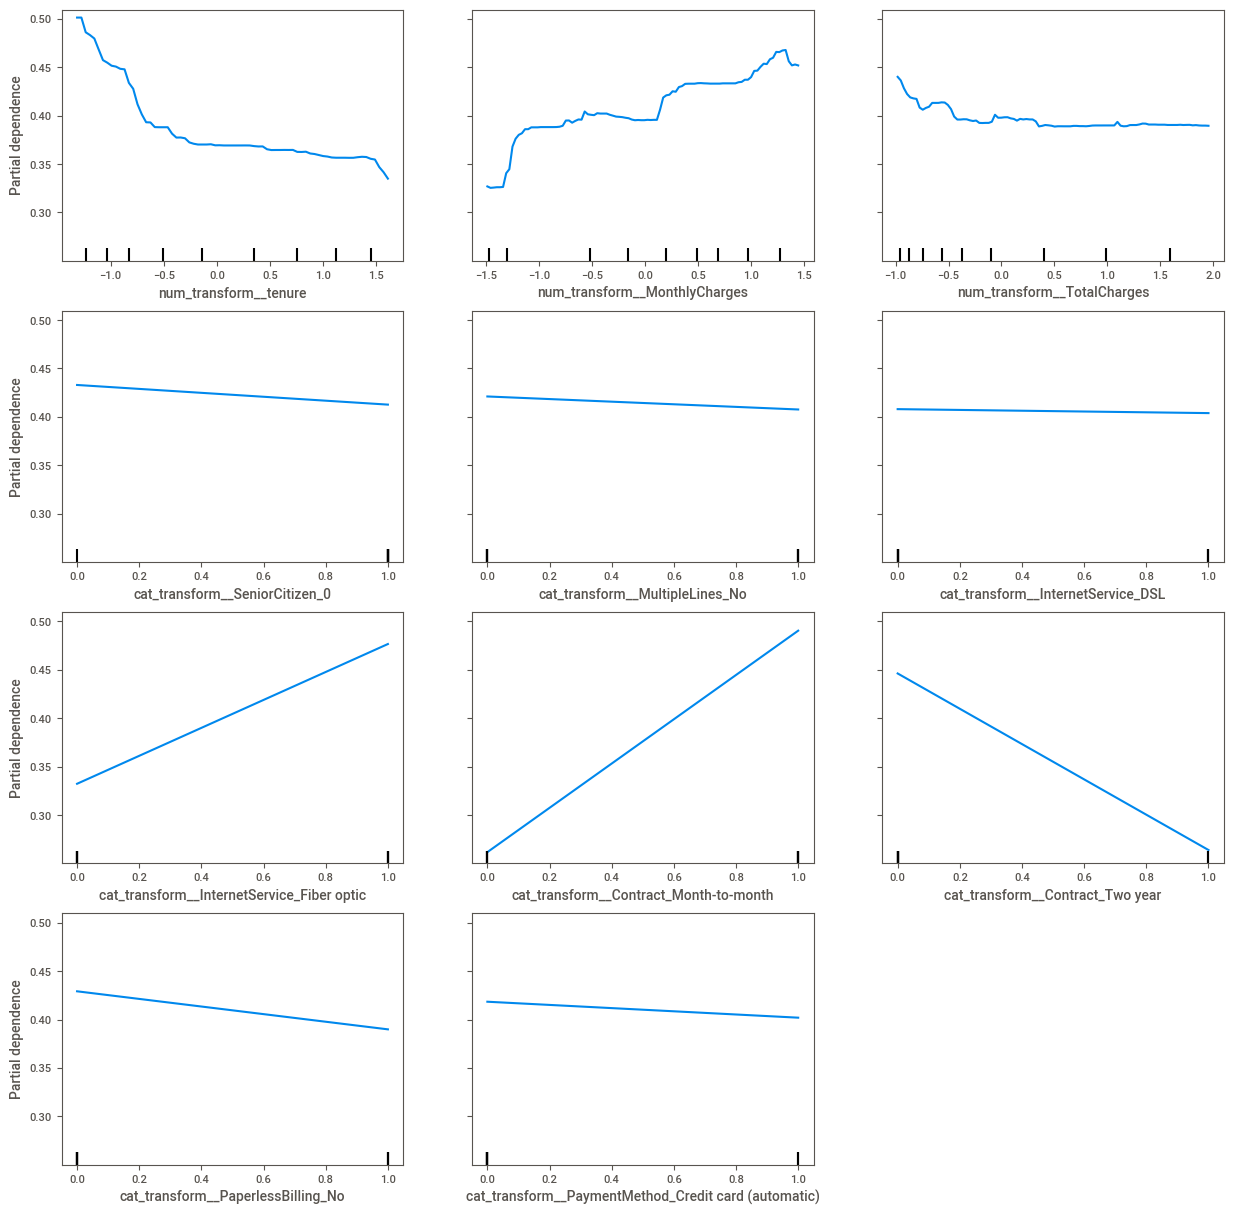

In [56]:
# ترسیم نمودار های Partial Dependence برای ویژگی های منتخب
fig, ax = plt.subplots(figsize=(15, 15))
display = PartialDependenceDisplay.from_estimator(estimator=estimator, X=X_selector, features=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], feature_names=feature_names, ax=ax)
plt.show()